# Planner Internalization Experiment

**Goal**: Fine-tune Gemma 4 E4B to internalize AssetOpsBench tool descriptions so it can produce correct MCP tool-use plans **without tool descriptions in the prompt** (blind mode).

## Experiment Structure

| Section | What |
|---------|------|
| **0. Setup & Data Audit** | Load data, detect contamination, build clean 80/20 split |
| **1. Understand the Data** | Show datasets, plan format, blind vs informed |
| **2. Baseline Evaluation** | Informed + blind eval on base model, Gemini judge |
| **3. Training Data Ablation** | 5 dataset configs, train + eval each |
| **4. LoRA Configuration Ablation** | QLoRA vs LoRA, rank sweep |
| **5. Catastrophic Forgetting** | 100 MCQ benchmark (MMLU + ARC + HellaSwag) |
| **6. Results & Analysis** | Aggregate tables, error analysis, token savings |

**Key constraint**: All evaluation steps use at most ~30 test scenarios + Gemini judge calls. Early stopping with convergence detection.

In [1]:
!pip install -q -U transformers peft trl accelerate bitsandbytes
!pip install -q -U datasets pandas matplotlib seaborn scikit-learn
!pip install -q -U litellm sentencepiece protobuf wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 50.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 158.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 163.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 155.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pa

In [2]:
import os, re, gc, json, math, time, random, warnings, inspect
from copy import deepcopy
from pathlib import Path
from collections import Counter, defaultdict
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import litellm
import wandb

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    GPU_MEM_GB = props.total_memory / 1e9
    print(f"gpu: {torch.cuda.get_device_name(0)} ({GPU_MEM_GB:.1f} GB)")
else:
    GPU_MEM_GB = 0

# ── Section timer ─────────────────────────────────────────────────────────
_section_times = {}
_section_start = None
_current_section = None

def start_timer(section_name):
    global _section_start, _current_section
    _current_section = section_name
    _section_start = time.time()
    print(f"\n{'>'*3} Starting: {section_name}")

def stop_timer():
    global _section_start, _current_section
    if _section_start is None:
        return
    elapsed = time.time() - _section_start
    _section_times[_current_section] = elapsed
    m, s = divmod(elapsed, 60)
    print(f"{'<'*3} {_current_section}: {int(m)}m {s:.0f}s")
    _section_start = None

def print_timing_summary():
    """Print timing summary and estimate full-run time from light-mode timings."""
    print("\n" + "="*70)
    print("TIMING SUMMARY")
    print("="*70)
    total = 0
    for section, elapsed in _section_times.items():
        m, s = divmod(elapsed, 60)
        print(f"  {section:45s} {int(m):3d}m {s:04.1f}s")
        total += elapsed
    m, s = divmod(total, 60)
    h, m = divmod(int(m), 60)
    print(f"  {'TOTAL':45s} {h}h {m}m {s:.0f}s")

    if LIGHT_MODE:
        # Estimate full-run time based on scaling factors
        print(f"\n  --- FULL RUN ESTIMATE ---")
        scale = {}
        full_eval = 30
        full_epochs = 3
        full_mcq = 100
        light_eval = MAX_EVAL_SCENARIOS
        light_mcq = MCQ_N_MMLU + MCQ_N_ARC + MCQ_N_HELLA

        for section, elapsed in _section_times.items():
            if "Baseline" in section or "judge" in section.lower():
                scale[section] = elapsed * (full_eval / max(light_eval, 1))
            elif "Train" in section or "ablation" in section.lower():
                scale[section] = elapsed * 30
            elif "LoRA" in section or "rank" in section.lower():
                scale[section] = elapsed * 15
            elif "Forgetting" in section or "MCQ" in section.lower():
                scale[section] = elapsed * (full_mcq / max(light_mcq, 1))
            else:
                scale[section] = elapsed * 5

        est_total = sum(scale.values())
        h, rem = divmod(int(est_total), 3600)
        m, s = divmod(rem, 60)
        for section, est in scale.items():
            em, es = divmod(est, 60)
            print(f"  {section:45s} ~{int(em):3d}m {es:04.1f}s")
        print(f"  {'ESTIMATED FULL TOTAL':45s} ~{h}h {m}m {s}s")

device: cuda
gpu: NVIDIA A100-SXM4-80GB (85.1 GB)


In [3]:
# ── Configuration ──────────────────────────────────────────────────────────
MODEL_ID = "google/gemma-4-E4B-it"

# ── Read secrets: try Colab userdata first, then env vars ─────────────────
def _get_secret(name):
    """Read a secret from Colab userdata or environment variables."""
    try:
        from google.colab import userdata
        val = userdata.get(name)
        if val:
            return val
    except (ImportError, ModuleNotFoundError, Exception):
        pass
    return os.environ.get(name, "")

HF_TOKEN = _get_secret("HF_TOKEN")
GEMINI_API_KEY = _get_secret("GEMINI_API_KEY")
WANDB_API_KEY = _get_secret("WANDB_API_KEY")
JUDGE_MODEL = "gemini/gemini-2.5-flash"

# Suppress litellm debug spam
litellm.suppress_debug_info = True

REPO_URL = "https://github.com/YuvalShemla/hpml-2026-project.git"
REPO_DIR = Path("/content/hpml-2026-project")
OUTPUT_DIR = Path("/content/output_internalization")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── LIGHT MODE ────────────────────────────────────────────────────────────
# Set True to do a fast smoke-test (~1 min per cell). Set False for full run.
LIGHT_MODE = False

if LIGHT_MODE:
    MAX_EVAL_SCENARIOS = 3        # only 3 test scenarios per eval
    DEFAULT_EPOCHS = 1            # single epoch
    MAX_TRAIN_EXAMPLES = 50       # cap training data
    MAX_NEW_TOKENS = 256
    EARLY_STOPPING_PATIENCE = 2
    RANK_SWEEP = [8, 16]          # only 2 ranks
    MCQ_N_MMLU, MCQ_N_ARC, MCQ_N_HELLA = 6, 4, 4  # 14 MCQ total
    print("LIGHT MODE: fast smoke-test (set LIGHT_MODE=False for full run)")
else:
    MAX_EVAL_SCENARIOS = 30
    DEFAULT_EPOCHS = 2
    MAX_TRAIN_EXAMPLES = None     # use all
    MAX_NEW_TOKENS = 512
    EARLY_STOPPING_PATIENCE = 2
    RANK_SWEEP = [8, 16, 32, 64]
    MCQ_N_MMLU, MCQ_N_ARC, MCQ_N_HELLA = 40, 30, 30  # 100 MCQ total
    print("FULL MODE: complete experiment")

# ── Adaptive GPU settings ─────────────────────────────────────────────────
if GPU_MEM_GB > 60:
    MAX_SEQ_LENGTH = 1024
    PER_DEVICE_BATCH_SIZE = 2
    GRADIENT_ACCUMULATION_STEPS = 4
else:
    MAX_SEQ_LENGTH = 512
    PER_DEVICE_BATCH_SIZE = 1
    GRADIENT_ACCUMULATION_STEPS = 8

# ── Training defaults (overridden per experiment) ─────────────────────────
DEFAULT_LR = 2e-4
DEFAULT_LORA_R = 16
DEFAULT_LORA_ALPHA = 32
LORA_DROPOUT = 0.05
WARMUP_RATIO = 0.05
WEIGHT_DECAY = 0.01

# ── Eval settings ─────────────────────────────────────────────────────────
TEMPERATURE = 0.1
TOP_P = 0.9
MIN_LOSS_DELTA = 0.005

# ── W&B configuration ────────────────────────────────────────────────────
WANDB_PROJECT = "hpml-asset-ops-group20"
WANDB_ENTITY = "group20"
WANDB_RUN_MODE = "debug" if LIGHT_MODE else "full-run"

# Login to W&B
if WANDB_API_KEY:
    wandb.login(key=WANDB_API_KEY)
    print(f"W&B logged in (project={WANDB_PROJECT}, mode={WANDB_RUN_MODE})")
else:
    print("W&B: no WANDB_API_KEY set — logging disabled")

# ── W&B helpers ──────────────────────────────────────────────────────────

def wb_run_tags():
    """Common tags for all runs."""
    tags = [WANDB_RUN_MODE, MODEL_ID.split("/")[-1]]
    if torch.cuda.is_available():
        tags.append(torch.cuda.get_device_name(0).replace(" ", "-"))
    return tags

def wb_base_config():
    """Base config dict logged with every W&B run."""
    return {
        "model_id": MODEL_ID,
        "light_mode": LIGHT_MODE,
        "max_seq_length": MAX_SEQ_LENGTH,
        "batch_size": PER_DEVICE_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "max_eval_scenarios": MAX_EVAL_SCENARIOS,
        "default_epochs": DEFAULT_EPOCHS,
        "max_train_examples": MAX_TRAIN_EXAMPLES,
        "lr": DEFAULT_LR,
        "lora_r": DEFAULT_LORA_R,
        "lora_alpha": DEFAULT_LORA_ALPHA,
        "lora_dropout": LORA_DROPOUT,
        "warmup_ratio": WARMUP_RATIO,
        "weight_decay": WEIGHT_DECAY,
        "temperature": TEMPERATURE,
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
        "gpu_mem_gb": GPU_MEM_GB,
    }

def wb_init(run_name, group, job_type, extra_config=None):
    """Initialize a W&B run with standard naming. Returns the run or None."""
    if not WANDB_API_KEY:
        return None
    config = wb_base_config()
    if extra_config:
        config.update(extra_config)
    run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=f"{'[DEBUG] ' if LIGHT_MODE else ''}{run_name}",
        group=group,
        job_type=job_type,
        tags=wb_run_tags() + ([job_type] if job_type else []),
        config=config,
        reinit=True,
    )
    return run

def wb_finish():
    """Finish current W&B run if active."""
    if wandb.run is not None:
        wandb.finish()

def wb_log_metrics_table(table_name, df, run=None):
    """Log a pandas DataFrame as a W&B Table."""
    if wandb.run is None and run is None:
        return
    tbl = wandb.Table(dataframe=df.reset_index(drop=True) if hasattr(df, 'reset_index') else df)
    wandb.log({table_name: tbl})

def wb_log_figure(fig_name, fig=None):
    """Log a matplotlib figure to W&B."""
    if wandb.run is None:
        return
    wandb.log({fig_name: wandb.Image(fig or plt.gcf())})

print(json.dumps({
    "model": MODEL_ID, "light_mode": LIGHT_MODE,
    "max_seq_length": MAX_SEQ_LENGTH, "batch_size": PER_DEVICE_BATCH_SIZE,
    "max_eval_scenarios": MAX_EVAL_SCENARIOS, "epochs": DEFAULT_EPOCHS,
    "hf_token_set": bool(HF_TOKEN),
    "gemini_key_set": bool(GEMINI_API_KEY),
    "wandb_key_set": bool(WANDB_API_KEY),
    "wandb_mode": WANDB_RUN_MODE,
}, indent=2))

FULL MODE: complete experiment


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: yakobeayal to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B logged in (project=hpml-asset-ops-group20, mode=full-run)
{
  "model": "google/gemma-4-E4B-it",
  "light_mode": false,
  "max_seq_length": 1024,
  "batch_size": 2,
  "max_eval_scenarios": 30,
  "epochs": 2,
  "hf_token_set": true,
  "gemini_key_set": true,
  "wandb_key_set": true,
  "wandb_mode": "full-run"
}


In [4]:
# ── Load repo and datasets ────────────────────────────────────────────────
if not REPO_DIR.exists():
    !git clone {REPO_URL} {REPO_DIR}
else:
    print("repo already present:", REPO_DIR)

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

datasets_dir = REPO_DIR / "benchmark" / "generate_data" / "datasets"
ds_tool = load_jsonl(datasets_dir / "tool_knowledge.jsonl")
ds_plan = load_jsonl(datasets_dir / "planning.jsonl")
ds_exec = load_jsonl(datasets_dir / "execution.jsonl")

gold_path = REPO_DIR / "benchmark" / "baseline_tests" / "gemini_flash_informed_results.json"
with open(gold_path) as f:
    gold_plans_raw = json.load(f)
gold_by_id = {g["id"]: g for g in gold_plans_raw if g.get("plan_steps", 0) > 0}

print(f"Datasets: tool={len(ds_tool)}, plan={len(ds_plan)}, exec={len(ds_exec)}")
print(f"Gold plans: {len(gold_by_id)}")

Cloning into '/content/hpml-2026-project'...
remote: Enumerating objects: 592, done.
remote: Counting objects: 100% (143/143), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 592 (delta 87), reused 97 (delta 45), pack-reused 449 (from 1)
Receiving objects: 100% (592/592), 57.63 MiB | 16.88 MiB/s, done.
Resolving deltas: 100% (144/144), done.
Datasets: tool=307, plan=1589, exec=120
Gold plans: 148


## 0. Data Audit & Clean Split

The training data (`planning.jsonl`) was generated from the **same** 152 HF scenarios used for evaluation. We check for contamination and build a clean 80/20 split at the scenario level.

In [5]:
# ── Contamination audit ───────────────────────────────────────────────────
from datasets import load_dataset as hf_load_dataset

hf_ds = hf_load_dataset("ibm-research/AssetOpsBench", "scenarios")
hf_scenarios = [dict(row) for row in hf_ds["train"]]

gold_questions = {g.get("prompt", "").strip().lower() for g in gold_plans_raw if g.get("prompt")}
train_questions = {d["messages"][0]["content"].strip().lower() for d in ds_plan}

exact_overlap = gold_questions & train_questions
print(f"Gold questions: {len(gold_questions)}")
print(f"Training questions: {len(train_questions)}")
print(f"EXACT OVERLAP: {len(exact_overlap)} ({100*len(exact_overlap)/max(len(gold_questions),1):.0f}% of gold)")
print()

# Show high-similarity near-misses
high_sim = 0
for gq in list(gold_questions)[:20]:
    best = max(
        ((tq, SequenceMatcher(None, gq, tq).ratio()) for tq in train_questions if tq != gq),
        key=lambda x: x[1], default=("", 0)
    )
    if best[1] > 0.7:
        high_sim += 1
print(f"High similarity (>0.7) matches in first 20 gold: {high_sim}/20")
print("=> 100% contamination confirmed. Building clean split...")

README.md: 0.00B [00:00, ?B/s]

all_utterance.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/152 [00:00<?, ? examples/s]

Gold questions: 150
Training questions: 1589
EXACT OVERLAP: 150 (100% of gold)

High similarity (>0.7) matches in first 20 gold: 16/20
=> 100% contamination confirmed. Building clean split...


In [6]:
# ── Pattern-aware stratified 80/20 split ──────────────────────────────────
# Each scenario gets a "pattern" = (type, tools_used, step_count).
# We split so train and test share the same patterns where possible.

for sc in hf_scenarios:
    g = gold_by_id.get(sc["id"], {})
    sc["tools"] = tuple(sorted(g.get("tools_used", [])))
    sc["steps"] = g.get("plan_steps", 0)
    sc["agents"] = tuple(sorted(g.get("agents_used", [])))
    sc["pattern"] = (sc["type"], sc["tools"], sc["steps"])
    sc["complexity"] = "simple" if sc["steps"] <= 2 else "complex"
    sc["gold_plan"] = g.get("response", "")
    sc["gold_prompt"] = g.get("prompt", sc["text"])

by_stratum = defaultdict(lambda: defaultdict(list))
for sc in hf_scenarios:
    by_stratum[(sc["type"], sc["complexity"])][sc["pattern"]].append(sc)

test_scenarios, train_scenarios = [], []
for stratum, pattern_groups in by_stratum.items():
    all_in = [sc for group in pattern_groups.values() for sc in group]
    n_test = max(1, round(len(all_in) * 0.20))

    test_pool, remaining = [], []
    for pattern, members in pattern_groups.items():
        random.shuffle(members)
        if len(members) >= 2:
            test_pool.append(members[0])
            remaining.extend(members[1:])
        else:
            remaining.extend(members)

    random.shuffle(test_pool)
    actual_test = test_pool[:n_test]
    remaining.extend(test_pool[n_test:])

    if len(actual_test) < n_test:
        shortfall = n_test - len(actual_test)
        random.shuffle(remaining)
        actual_test.extend(remaining[:shortfall])
        remaining = remaining[shortfall:]

    for sc in actual_test:
        sc["test_kind"] = "seen_pattern" if any(
            sc["pattern"] == t["pattern"] for t in remaining
        ) else "novel_pattern"

    test_scenarios.extend(actual_test)
    train_scenarios.extend(remaining)

# Cap test to MAX_EVAL_SCENARIOS
if len(test_scenarios) > MAX_EVAL_SCENARIOS:
    random.shuffle(test_scenarios)
    test_scenarios = test_scenarios[:MAX_EVAL_SCENARIOS]

test_ids = {sc["id"] for sc in test_scenarios}
test_questions_set = {sc["text"].strip().lower() for sc in test_scenarios}
test_prompts_set = {sc["gold_prompt"].strip().lower() for sc in test_scenarios}
all_test_qs = test_questions_set | test_prompts_set

# Filter training data: remove anything from test scenarios
def is_contaminated(question, threshold=0.8):
    q = question.strip().lower()
    if q in all_test_qs:
        return True
    for tq in all_test_qs:
        if SequenceMatcher(None, q, tq).ratio() > threshold:
            return True
    return False

clean_plan = [ex for ex in ds_plan if not is_contaminated(ex["messages"][0]["content"])]
clean_exec = [ex for ex in ds_exec if not is_contaminated(ex["messages"][0]["content"])]
clean_tool = ds_tool  # no scenario-specific questions

# Validate
train_qs = {ex["messages"][0]["content"].strip().lower() for ex in clean_plan + clean_exec}
leaked = train_qs & all_test_qs
assert len(leaked) == 0, f"LEAKAGE: {len(leaked)} questions in both train and test!"

n_seen = sum(1 for s in test_scenarios if s.get("test_kind") == "seen_pattern")
n_novel = sum(1 for s in test_scenarios if s.get("test_kind") == "novel_pattern")
type_dist = Counter(s["type"] for s in test_scenarios)

print(f"Train scenarios: {len(train_scenarios)} | Test scenarios: {len(test_scenarios)}")
print(f"Test breakdown: {n_seen} seen-pattern, {n_novel} novel-pattern")
print(f"Test type dist: {dict(type_dist)}")
print(f"Clean train: {len(clean_tool)} tool + {len(clean_plan)} plan + {len(clean_exec)} exec")
print(f"Leakage check: PASSED (0 leaked)")

Train scenarios: 122 | Test scenarios: 30
Test breakdown: 29 seen-pattern, 1 novel-pattern
Test type dist: {'IoT': 4, 'FMSA': 4, 'TSFM': 5, 'Workorder': 9, 'multiagent': 8}
Clean train: 307 tool + 1526 plan + 79 exec
Leakage check: PASSED (0 leaked)


## 1. Understand the Data

Three training datasets, each teaching a different aspect of tool knowledge:
- **tool_knowledge** (307): What agents/tools exist, who owns them, their arguments, hard negatives
- **planning** (1,589): Question → structured plan (#Task/#Agent/#Tool/#Args/#Dependency)
- **execution** (120): Question → plan + execution trace with resolved arguments

In [7]:
# ── Show examples from each dataset ───────────────────────────────────────
for name, ds, n in [("tool_knowledge", ds_tool, 3), ("planning", ds_plan, 2), ("execution", ds_exec, 1)]:
    print(f"\n{'='*70}\n{name.upper()} ({len(ds)} examples)\n{'='*70}")
    cats = Counter(d.get("metadata", {}).get("category", "?") for d in ds)
    print(f"Categories: {dict(cats)}\n")
    for ex in ds[:n]:
        print(f"  USER: {ex['messages'][0]['content'][:120]}")
        print(f"  ASST: {ex['messages'][1]['content'][:200]}")
        print()


TOOL_KNOWLEDGE (307 examples)
Categories: {'agent_listing': 1, 'tool_listing': 6, 'tool_ownership': 31, 'tool_arguments': 31, 'tool_routing': 23, 'hard_negative': 52, 'clarification': 45, 'tool_knowledge_varied': 63, 'tool_routing_varied': 55}

  USER: What are all the available sub-agents in the AssetOpsBench system?
  ASST: The available sub-agents are: IoTAgent, FMSRAgent, TSFMAgent, Utilities, WorkOrderAgent, VibrationAgent.

  USER: What tools does IoTAgent provide?
  ASST: IoTAgent provides these tools: sites, assets, sensors, history. Handles IoT telemetry data access — sites, assets, sensors, and historical readings from industrial equipment.

  USER: What tools does FMSRAgent provide?
  ASST: FMSRAgent provides these tools: get_failure_modes, get_failure_mode_sensor_mapping. Provides failure mode analysis and sensor relevance reasoning for industrial assets.


PLANNING (1589 examples)
Categories: {'planning': 1520, 'planning_clarification': 69}

  USER: What IoT sites are ava

## 2. Evaluation Infrastructure

We define:
1. **Plan parser** — extract structured steps from model output
2. **Structural metrics** — agent-tool F1, arg key F1, dependency F1
3. **Gemini LLM-as-judge** — 6-dimension rating (1-5) via API
4. **Informed vs Blind prompts** — the key comparison

In [8]:
# ── Prompts ────────────────────────────────────────────────────────────────

TOOL_DESCRIPTIONS = """Available Agents and Tools:

IoTAgent:
  - sites(): List all available IoT sites
  - assets(site_name): List assets at a site
  - sensors(site_name, asset_id): List sensors for an asset
  - history(site_name, asset_id, start, final=None): Get sensor history

FMSRAgent:
  - get_failure_modes(asset_name): Get failure modes for an asset
  - get_failure_mode_sensor_mapping(asset_name, failure_modes, sensors): Map failure modes to sensors

TSFMAgent:
  - get_ai_tasks(): List available AI tasks
  - get_tsfm_models(): List time-series models
  - run_tsfm_forecasting(...): Run forecasting
  - run_tsfm_finetuning(...): Fine-tune a TSFM model
  - run_tsad(...): Run anomaly detection
  - run_integrated_tsad(...): Run integrated anomaly detection

Utilities:
  - json_reader(file_name): Read a JSON file
  - current_date_time(): Get current date/time
  - current_time_english(): Get current time in English

WorkOrderAgent:
  - get_work_orders(asset_name): Get work orders
  - get_preventive_work_orders(asset_name): Get preventive work orders
  - get_corrective_work_orders(asset_name): Get corrective work orders
  - get_events(asset_name): Get events
  - get_failure_codes(asset_name): Get failure codes
  - get_work_order_distribution(asset_name): Get work order distribution
  - predict_next_work_order(asset_name): Predict next work order
  - analyze_alert_to_failure(asset_name): Analyze alert-to-failure patterns
"""

INFORMED_PROMPT = """You are an expert planner for industrial asset operations. Given a question and available tools, produce a structured plan.

{tool_descriptions}

OUTPUT FORMAT (one block per step):
#Task1: <description>
#Agent1: <agent_name>
#Tool1: <tool_name>
#Args1: {{"arg": "value"}}
#Dependency1: None
#ExpectedOutput1: <what to expect>

Rules: Use only listed agents/tools. Keep plans concise. Use {{step_N}} for dependencies.

QUESTION: {question}
"""

BLIND_PROMPT = """You are an expert planner for industrial asset operations. Produce a structured plan.

OUTPUT FORMAT (one block per step):
#Task1: <description>
#Agent1: <agent_name>
#Tool1: <tool_name>
#Args1: {{"arg": "value"}}
#Dependency1: None
#ExpectedOutput1: <what to expect>

Rules: Keep plans concise. Use {{step_N}} for dependencies.

QUESTION: {question}
"""

def print_exact_token_counts(tokenizer):
    """Print exact token counts using the model's tokenizer (call after model is loaded)."""
    sample_q = "What IoT sites are available?"
    informed_text = INFORMED_PROMPT.format(tool_descriptions=TOOL_DESCRIPTIONS, question=sample_q)
    blind_text = BLIND_PROMPT.format(question=sample_q)
    n_informed = len(tokenizer.encode(informed_text))
    n_blind = len(tokenizer.encode(blind_text))
    print(f"Exact token counts (sample: '{sample_q}'):")
    print(f"  Informed prompt: {n_informed} tokens")
    print(f"  Blind prompt:    {n_blind} tokens")
    print(f"  Tool description overhead: {n_informed - n_blind} tokens ({100*(n_informed - n_blind)/n_informed:.0f}%)")
    return n_informed, n_blind

print("Prompts defined. Token counts will be printed after model loading.")

Prompts defined. Token counts will be printed after model loading.


In [9]:
# ── Plan parser & structural metrics ──────────────────────────────────────
VALID_AGENTS = {"IoTAgent", "FMSRAgent", "TSFMAgent", "Utilities", "WorkOrderAgent", "VibrationAgent", "none"}
VALID_TOOLS = {
    "sites", "assets", "sensors", "history",
    "get_failure_modes", "get_failure_mode_sensor_mapping",
    "get_ai_tasks", "get_tsfm_models", "run_tsfm_forecasting",
    "run_tsfm_finetuning", "run_tsad", "run_integrated_tsad",
    "json_reader", "current_date_time", "current_time_english",
    "get_work_orders", "get_preventive_work_orders", "get_corrective_work_orders",
    "get_events", "get_failure_codes", "get_work_order_distribution",
    "predict_next_work_order", "analyze_alert_to_failure", "none",
}

def parse_plan(text):
    steps = []
    if not text:
        return steps
    for block in re.split(r"(?=#Task\d+:)", text):
        block = block.strip()
        task_m = re.search(r"#Task(\d+):\s*(.*)", block)
        agent_m = re.search(r"#Agent\d+:\s*(\S+)", block)
        tool_m = re.search(r"#Tool\d+:\s*(\S+)", block)
        args_m = re.search(r"#Args\d+:\s*(.*)", block)
        dep_m = re.search(r"#Dependency\d+:\s*(.*)", block)
        if not task_m:
            continue
        args_raw = args_m.group(1).strip() if args_m else "{}"
        try:
            args = json.loads(args_raw)
        except Exception:
            args = {}
        steps.append({
            "step": int(task_m.group(1)),
            "task": task_m.group(2).strip(),
            "agent": agent_m.group(1).strip() if agent_m else "",
            "tool": tool_m.group(1).strip().rstrip("()") if tool_m else "",
            "args": args,
            "dependency": dep_m.group(1).strip() if dep_m else "None",
        })
    return steps

def set_f1(gold, pred):
    g, p = set(gold), set(pred)
    if not g and not p: return 1.0
    if not g or not p: return 0.0
    tp = len(g & p)
    prec, rec = tp / len(p), tp / len(g)
    return 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0

def evaluate_plan(pred_text, gold_text):
    pred_steps, gold_steps = parse_plan(pred_text), parse_plan(gold_text)
    pred_pairs = [(s["agent"], s["tool"]) for s in pred_steps if s["tool"]]
    gold_pairs = [(s["agent"], s["tool"]) for s in gold_steps if s["tool"]]

    gold_args = {(s["agent"], s["tool"]): s["args"] for s in gold_steps if s["args"]}
    key_scores = []
    for s in pred_steps:
        k = (s["agent"], s["tool"])
        if k in gold_args:
            key_scores.append(set_f1(gold_args[k].keys(), s["args"].keys() if isinstance(s["args"], dict) else []))

    return {
        "has_format": "#Task" in (pred_text or "") and "#Agent" in (pred_text or ""),
        "num_steps": len(pred_steps),
        "gold_steps": len(gold_steps),
        "agent_tool_f1": set_f1(gold_pairs, pred_pairs),
        "arg_key_f1": float(np.mean(key_scores)) if key_scores else 0.0,
        "valid_agents": sum(1 for s in pred_steps if s["agent"] in VALID_AGENTS),
        "valid_tools": sum(1 for s in pred_steps if s["tool"] in VALID_TOOLS),
        "total_steps_pred": len(pred_steps),
    }

def summarize_metrics(results):
    if not results: return {}
    return {
        "n": len(results),
        "format_%": 100 * np.mean([r["has_format"] for r in results]),
        "AT-F1": float(np.mean([r["agent_tool_f1"] for r in results])),
        "ArgKey-F1": float(np.mean([r["arg_key_f1"] for r in results])),
        "agent_%": sum(r["valid_agents"] for r in results) / max(sum(r["total_steps_pred"] for r in results), 1),
        "tool_%": sum(r["valid_tools"] for r in results) / max(sum(r["total_steps_pred"] for r in results), 1),
    }

print("Evaluation functions defined.")


Evaluation functions defined.


In [10]:
# ── Gemini LLM-as-Judge ───────────────────────────────────────────────────

JUDGE_PROMPT = """You are evaluating an AI-generated MCP tool-use plan against a gold reference.

## Question
{question}

## Gold Reference Plan
{gold_plan}

## Candidate Plan
{candidate_plan}

## Available Agents & Tools
- IoTAgent: sites(), assets(site_name), sensors(site_name, asset_id), history(...)
- FMSRAgent: get_failure_modes(asset_name), get_failure_mode_sensor_mapping(...)
- TSFMAgent: get_ai_tasks(), get_tsfm_models(), run_tsfm_forecasting(...), run_tsad(...), ...
- Utilities: json_reader(...), current_date_time(), current_time_english()
- WorkOrderAgent: get_work_orders(...), get_preventive_work_orders(...), predict_next_work_order(...), ...

Rate 1-5 on each:
1. correctness: Would this plan answer the question?
2. agent_routing: Are the correct agents assigned?
3. tool_selection: Are the correct tools selected?
4. argument_quality: Are tool arguments correct?
5. efficiency: Is the plan appropriately sized?
6. dependency_correctness: Are step dependencies correct?

Respond ONLY with JSON (no markdown fences):
{{"correctness": N, "agent_routing": N, "tool_selection": N, "argument_quality": N, "efficiency": N, "dependency_correctness": N}}
"""

def judge_plan(question, gold_plan, candidate_plan):
    """Call Gemini to judge a plan. Returns dict with 6 scores or None on error."""
    if not GEMINI_API_KEY:
        return None

    prompt = JUDGE_PROMPT.format(
        question=question,
        gold_plan=gold_plan or "(no gold plan)",
        candidate_plan=candidate_plan or "(empty)",
    )
    for attempt in range(3):
        try:
            resp = litellm.completion(
                model=JUDGE_MODEL, messages=[{"role": "user", "content": prompt}],
                temperature=0,
                max_tokens=8192,  # Gemini 2.5 Flash uses ~900 thinking tokens internally
                api_key=GEMINI_API_KEY,
            )
            raw = resp.choices[0].message.content or ""
            raw = raw.strip()
            # Strip markdown fences if present
            if raw.startswith("```"):
                lines = raw.splitlines()
                raw = "\n".join(lines[1:-1] if lines[-1].strip() == "```" else lines[1:])
                raw = raw.lstrip("json").strip()
            start, end = raw.find("{"), raw.rfind("}") + 1
            if start >= 0 and end > start:
                return json.loads(raw[start:end])
        except json.JSONDecodeError:
            pass  # retry
        except Exception as e:
            err = str(e).lower()
            if "429" in err or "rate" in err or "503" in err or "unavailable" in err:
                time.sleep(10 * (attempt + 1))
            elif attempt < 2:
                time.sleep(3)
            else:
                print(f"  Judge error: {type(e).__name__}: {str(e)[:100]}")
                return None
    return None

def run_judge_eval(results, test_scenarios):
    """Run Gemini judge on a list of eval results. Returns list of judge scores."""
    if not GEMINI_API_KEY:
        print("  Skipping Gemini judge (no GEMINI_API_KEY set)")
        return []
    gold_lookup = {sc["id"]: sc for sc in test_scenarios}
    judge_results = []
    for r in tqdm(results, desc="Gemini judge"):
        sc = gold_lookup.get(r["id"])
        if not sc:
            continue
        verdict = judge_plan(sc["gold_prompt"], sc["gold_plan"], r.get("generated", ""))
        if verdict:
            verdict["id"] = r["id"]
            judge_results.append(verdict)
        time.sleep(0.5)  # rate limit
    print(f"  Judged {len(judge_results)}/{len(results)} scenarios")
    return judge_results

def summarize_judge(judge_results):
    if not judge_results: return {}
    dims = ["correctness", "agent_routing", "tool_selection", "argument_quality", "efficiency", "dependency_correctness"]
    summary = {"n": len(judge_results)}
    for d in dims:
        vals = [r[d] for r in judge_results if d in r]
        summary[d] = float(np.mean(vals)) if vals else 0.0
    all_scores = [np.mean([r.get(d, 0) for d in dims]) for r in judge_results]
    summary["overall"] = float(np.mean(all_scores))
    return summary

# Quick smoke test of judge API
if GEMINI_API_KEY:
    _test = judge_plan("What sites?", "#Task1: Get sites\n#Agent1: IoTAgent\n#Tool1: sites", "#Task1: Sites\n#Agent1: IoTAgent\n#Tool1: sites")
    if _test:
        print(f"Gemini judge test: OK (correctness={_test.get('correctness', '?')})")
    else:
        print("Gemini judge test: FAILED — check GEMINI_API_KEY")
else:
    print("Gemini judge: DISABLED (no GEMINI_API_KEY)")

Gemini judge test: OK (correctness=5)


In [11]:
# ── Model loading, inference, and evaluation runner ───────────────────────
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, EarlyStoppingCallback
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer
from datasets import Dataset

def load_base_model(load_in_8bit=True, load_in_4bit=False):
    """Load Gemma 4 E4B with quantization."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if load_in_4bit:
        bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                  bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)
        label = "4-bit NF4"
    elif load_in_8bit:
        bnb = BitsAndBytesConfig(load_in_8bit=True)
        label = "8-bit"
    else:
        bnb = None
        label = "bf16 (no quant)"

    print(f"Loading {MODEL_ID} [{label}]...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
    model_kwargs = dict(device_map="auto", dtype=torch.bfloat16, token=HF_TOKEN, attn_implementation="eager")
    if bnb:
        model_kwargs["quantization_config"] = bnb
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, **model_kwargs)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        model.config.pad_token_id = tokenizer.eos_token_id
    return model, tokenizer

def setup_lora(base_model, r=DEFAULT_LORA_R, alpha=DEFAULT_LORA_ALPHA):
    peft_model = prepare_model_for_kbit_training(base_model)
    config = LoraConfig(r=r, lora_alpha=alpha, lora_dropout=LORA_DROPOUT,
                        target_modules="all-linear", bias="none", task_type=TaskType.CAUSAL_LM)
    peft_model = get_peft_model(peft_model, config)
    trainable, total = peft_model.get_nb_trainable_parameters()
    print(f"LoRA r={r}, alpha={alpha} -> trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
    return peft_model

def generate_plan(model, tokenizer, question, prompt_template, tool_desc=""):
    """Generate a plan from a prompt template."""
    if "{tool_descriptions}" in prompt_template:
        prompt = prompt_template.format(tool_descriptions=tool_desc, question=question)
    else:
        prompt = prompt_template.format(question=question)

    chat = [{"role": "user", "content": prompt}]
    tok = tokenizer.apply_chat_template(chat, return_tensors="pt", add_generation_prompt=True, return_dict=True)
    input_ids = tok["input_ids"].to(model.device)
    attn = tok["attention_mask"].to(model.device)
    input_len = input_ids.shape[1]

    with torch.no_grad():
        out = model.generate(input_ids=input_ids, attention_mask=attn,
                             max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE,
                             top_p=TOP_P, do_sample=True,
                             pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id)
    generated = tokenizer.decode(out[0][input_len:], skip_special_tokens=True)
    return generated, input_len

def run_eval(model, tokenizer, scenarios, prompt_template, mode_name, tool_desc=""):
    """Run plan generation + structural eval on test scenarios."""
    results = []
    for sc in tqdm(scenarios[:MAX_EVAL_SCENARIOS], desc=mode_name):
        q = sc.get("gold_prompt", sc["text"])
        gold = sc["gold_plan"]
        gen, n_input = generate_plan(model, tokenizer, q, prompt_template, tool_desc)
        metrics = evaluate_plan(gen, gold)
        metrics.update({"id": sc["id"], "type": sc["type"], "question": q,
                        "gold_plan": gold, "generated": gen,
                        "input_tokens": n_input, "mode": mode_name,
                        "test_kind": sc.get("test_kind", "")})
        results.append(metrics)
    return results

def wb_log_eval_table(results, judge_results=None, table_name="eval_predictions"):
    """Log a W&B Table with generated vs gold plans, structural metrics, and judge scores."""
    if wandb.run is None or not results:
        return
    # Build judge lookup by scenario ID
    judge_by_id = {}
    if judge_results:
        for j in judge_results:
            judge_by_id[j["id"]] = j

    rows = []
    for r in results:
        row = {
            "id": r["id"],
            "type": r["type"],
            "mode": r.get("mode", ""),
            "question": r["question"][:300],
            "gold_plan": r.get("gold_plan", "")[:500],
            "generated_plan": r.get("generated", "")[:500],
            "AT-F1": r["agent_tool_f1"],
            "ArgKey-F1": r["arg_key_f1"],
            "has_format": r["has_format"],
            "num_steps_pred": r["num_steps"],
            "num_steps_gold": r["gold_steps"],
            "input_tokens": r["input_tokens"],
        }
        # Add per-scenario judge scores if available
        jd = judge_by_id.get(r["id"], {})
        row["judge_overall"] = np.mean([jd.get(d, 0) for d in
            ["correctness", "agent_routing", "tool_selection", "argument_quality", "efficiency", "dependency_correctness"]]) if jd else None
        row["judge_correctness"] = jd.get("correctness")
        row["judge_tool_selection"] = jd.get("tool_selection")
        row["judge_agent_routing"] = jd.get("agent_routing")
        row["judge_argument_quality"] = jd.get("argument_quality")
        rows.append(row)

    wb_log_metrics_table(table_name, pd.DataFrame(rows))

    # Log aggregate metrics
    summary = summarize_metrics(results)
    for k, v in summary.items():
        if isinstance(v, (int, float)):
            wandb.log({f"eval/{k}": v})

print("Model / training / eval infrastructure ready.")


Model / training / eval infrastructure ready.


In [12]:
# ── Training function with early stopping + W&B logging ──────────────────

def train_model(peft_model, tokenizer, train_data, eval_data=None, output_dir="./out",
                epochs=DEFAULT_EPOCHS, lr=DEFAULT_LR, run_name="train",
                wb_group=None, wb_extra_config=None):
    """SFT training with early stopping and W&B logging.

    Training curves (train_loss, eval_loss, learning_rate) are automatically
    streamed to W&B via HuggingFace's built-in integration (report_to='wandb').
    After training, an explicit overlay chart of train vs eval loss is logged.
    """
    os.makedirs(output_dir, exist_ok=True)
    train_ds = Dataset.from_list(train_data)
    eval_ds = Dataset.from_list(eval_data) if eval_data else None

    total_steps = max(1, len(train_ds) * epochs // max(PER_DEVICE_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS, 1))
    warmup_steps = max(1, int(total_steps * WARMUP_RATIO))

    # Adaptive logging/eval frequency: log every step if <20 steps, else ~10 logs per run
    logging_steps = max(1, min(10, total_steps // 10))
    eval_steps = max(1, total_steps // max(epochs * 4, 4))  # ~4 evals per epoch for better curves

    # ── W&B run init (creates a run that SFTTrainer will adopt) ───────────
    wb_run = None
    report_to = "none"
    if WANDB_API_KEY:
        wb_config = wb_base_config()
        wb_config.update({
            "run_name": run_name,
            "train_examples": len(train_ds),
            "eval_examples": len(eval_ds) if eval_ds else 0,
            "epochs": epochs,
            "lr": lr,
            "total_steps_est": total_steps,
            "warmup_steps": warmup_steps,
            "logging_steps": logging_steps,
            "eval_steps": eval_steps,
        })
        if wb_extra_config:
            wb_config.update(wb_extra_config)

        wb_run = wandb.init(
            project=WANDB_PROJECT,
            entity=WANDB_ENTITY,
            name=f"{'[DEBUG] ' if LIGHT_MODE else ''}{run_name}",
            group=wb_group or "training",
            job_type="train",
            tags=wb_run_tags() + ["train", wb_group or "training"],
            config=wb_config,
            reinit=True,
        )
        report_to = "wandb"

    sft_kwargs = dict(
        output_dir=output_dir, run_name=run_name,
        num_train_epochs=epochs,
        per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
        per_device_eval_batch_size=PER_DEVICE_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        learning_rate=lr, lr_scheduler_type="cosine",
        warmup_steps=warmup_steps, weight_decay=WEIGHT_DECAY,
        bf16=True, logging_steps=logging_steps,
        eval_strategy="steps" if eval_ds else "no",
        eval_steps=eval_steps if eval_ds else None,
        save_strategy="steps", save_steps=eval_steps,
        save_total_limit=2,
        load_best_model_at_end=bool(eval_ds),
        metric_for_best_model="eval_loss" if eval_ds else None,
        greater_is_better=False if eval_ds else None,
        report_to=report_to, seed=SEED,
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        remove_unused_columns=False,
    )
    if "max_seq_length" in inspect.signature(SFTConfig.__init__).parameters:
        sft_kwargs["max_seq_length"] = MAX_SEQ_LENGTH
    sft_config = SFTConfig(**sft_kwargs)

    callbacks = []
    if eval_ds:
        callbacks.append(EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=MIN_LOSS_DELTA,
        ))

    trainer_kwargs = {"model": peft_model, "args": sft_config,
                      "train_dataset": train_ds, "processing_class": tokenizer,
                      "callbacks": callbacks}
    if eval_ds:
        trainer_kwargs["eval_dataset"] = eval_ds
    if "max_seq_length" in inspect.signature(SFTTrainer.__init__).parameters and "max_seq_length" not in sft_kwargs:
        trainer_kwargs["max_seq_length"] = MAX_SEQ_LENGTH

    trainer = SFTTrainer(**trainer_kwargs)
    trainer.train()

    # Extract training history
    history = trainer.state.log_history
    train_losses = [(h["step"], h["loss"]) for h in history if "loss" in h]
    eval_losses = [(h["step"], h["eval_loss"]) for h in history if "eval_loss" in h]
    learning_rates = [(h["step"], h["learning_rate"]) for h in history if "learning_rate" in h]
    stopped_early = trainer.state.global_step < total_steps and len(eval_losses) > EARLY_STOPPING_PATIENCE

    # ── Log learning curves + summary to W&B ──────────────────────────────
    if wb_run:
        final_train_loss = train_losses[-1][1] if train_losses else None
        final_eval_loss = eval_losses[-1][1] if eval_losses else None
        wandb.summary["final_train_loss"] = final_train_loss
        wandb.summary["final_eval_loss"] = final_eval_loss
        wandb.summary["stopped_early"] = stopped_early
        wandb.summary["actual_steps"] = trainer.state.global_step

        # Log raw loss data as W&B Table
        loss_rows = []
        for step, loss in train_losses:
            loss_rows.append({"step": step, "train_loss": loss, "eval_loss": None})
        for step, loss in eval_losses:
            found = False
            for row in loss_rows:
                if row["step"] == step:
                    row["eval_loss"] = loss
                    found = True
                    break
            if not found:
                loss_rows.append({"step": step, "train_loss": None, "eval_loss": loss})
        loss_rows.sort(key=lambda r: r["step"])
        if loss_rows:
            wb_log_metrics_table("learning_curve_data", pd.DataFrame(loss_rows))

        # Plot train vs eval loss overlay
        if train_losses or eval_losses:
            fig, ax1 = plt.subplots(figsize=(10, 5))
            if train_losses:
                t_steps, t_vals = zip(*train_losses)
                ax1.plot(t_steps, t_vals, "b-o", alpha=0.7, label="Train Loss", linewidth=1.5, markersize=4)
            if eval_losses:
                e_steps, e_vals = zip(*eval_losses)
                ax1.plot(e_steps, e_vals, "r-s", label="Eval Loss", linewidth=2, markersize=6)
            ax1.set_xlabel("Step")
            ax1.set_ylabel("Loss")
            ax1.set_title(f"Learning Curves: {run_name}")
            ax1.legend(loc="upper left")
            ax1.grid(True, alpha=0.3)

            if learning_rates:
                ax2 = ax1.twinx()
                lr_steps, lr_vals = zip(*learning_rates)
                ax2.plot(lr_steps, lr_vals, "g--", alpha=0.4, label="Learning Rate", linewidth=1)
                ax2.set_ylabel("Learning Rate", color="green")
                ax2.tick_params(axis="y", labelcolor="green")
                ax2.legend(loc="upper right")

            if stopped_early:
                ax1.axvline(x=trainer.state.global_step, color="orange", linestyle="--", alpha=0.7)

            plt.tight_layout()
            wb_log_figure("learning_curves")
            plt.close(fig)

    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    print(f"Training complete: {trainer.state.global_step}/{total_steps} steps"
          + (f" [logging every {logging_steps} steps, eval every {eval_steps} steps]")
          + (" [EARLY STOPPED]" if stopped_early else ""))
    return trainer, {"train_losses": train_losses, "eval_losses": eval_losses,
                     "stopped_early": stopped_early, "total_steps": trainer.state.global_step}

print("Training function with early stopping + W&B logging defined.")

Training function with early stopping + W&B logging defined.


## 2. Baseline Evaluation

Load the base model (no fine-tuning) and evaluate in:
1. **Informed mode** — full tool descriptions in prompt (upper bound)
2. **Blind mode** — no tool descriptions (lower bound, should be ~0%)

In [13]:
# ── SKIPPED: Model loading (not needed — baselines hardcoded, quant/rank hardcoded)
# The forgetting section will load its own fresh models.
base_model = None  # placeholder so del base_model doesn't crash in quant cell
print("Base model loading SKIPPED — hardcoded results from run_2 and run_3.")

Base model loading SKIPPED — hardcoded results from run_2 and run_3.


In [14]:
# ── SKIPPED: Baseline informed eval (completed in run_2) ───────────────────
baseline_informed_summary = {
    "n": 30, "format_%": 100.0, "AT-F1": 0.470, "ArgKey-F1": 0.600,
    "agent_%": 0.850, "tool_%": 0.903,
}
baseline_informed = []  # raw results not needed for downstream
print("Baseline Informed (from run_2):", json.dumps(baseline_informed_summary, indent=2))


Baseline Informed (from run_2): {
  "n": 30,
  "format_%": 100.0,
  "AT-F1": 0.47,
  "ArgKey-F1": 0.6,
  "agent_%": 0.85,
  "tool_%": 0.903
}


In [15]:
# ── SKIPPED: Baseline blind eval (completed in run_2) ─────────────────────
baseline_blind_summary = {
    "n": 30, "format_%": 100.0, "AT-F1": 0.0, "ArgKey-F1": 0.0,
    "agent_%": 0.0, "tool_%": 0.0,
}
baseline_blind = []
print("Baseline Blind (from run_2):", json.dumps(baseline_blind_summary, indent=2))


Baseline Blind (from run_2): {
  "n": 30,
  "format_%": 100.0,
  "AT-F1": 0.0,
  "ArgKey-F1": 0.0,
  "agent_%": 0.0,
  "tool_%": 0.0
}


In [16]:
# ── SKIPPED: Gemini judge on baselines (completed in run_2) ────────────────
baseline_informed_judge = [{"correctness": 2.133, "agent_routing": 3.967, "tool_selection": 2.667,
                            "argument_quality": 2.567, "efficiency": 2.367, "dependency_correctness": 3.6}]
baseline_blind_judge = [{"correctness": 1.2, "agent_routing": 1.1, "tool_selection": 1.0,
                         "argument_quality": 1.333, "efficiency": 2.167, "dependency_correctness": 4.5}]

baseline_df = pd.DataFrame([
    {"mode": "Informed (upper bound)", **baseline_informed_summary,
     "judge_n": 30, "judge_correctness": 2.133, "judge_agent_routing": 3.967,
     "judge_tool_selection": 2.667, "judge_argument_quality": 2.567,
     "judge_efficiency": 2.367, "judge_dependency_correctness": 3.6, "judge_overall": 2.883},
    {"mode": "Blind (lower bound)", **baseline_blind_summary,
     "judge_n": 30, "judge_correctness": 1.2, "judge_agent_routing": 1.1,
     "judge_tool_selection": 1.0, "judge_argument_quality": 1.333,
     "judge_efficiency": 2.167, "judge_dependency_correctness": 4.5, "judge_overall": 1.883},
])
print("=== BASELINE COMPARISON (from run_2) ===")
display(baseline_df.round(3))
print("Token savings: 573 (informed) -> 139 (blind) = 434 tokens saved (76%)")
avg_informed_tokens, avg_blind_tokens = 573, 139
token_savings, token_pct = 434, 76


=== BASELINE COMPARISON (from run_2) ===


,mode,n,format_%,AT-F1,ArgKey-F1,agent_%,tool_%,judge_n,judge_correctness,judge_agent_routing,judge_tool_selection,judge_argument_quality,judge_efficiency,judge_dependency_correctness,judge_overall
0,Informed (upper bound),30,100.0,0.47,0.6,0.85,0.903,30,2.133,3.967,2.667,2.567,2.367,3.6,2.883
1,Blind (lower bound),30,100.0,0.00,0.0,0.00,0.000,30,1.200,1.100,1.000,1.333,2.167,4.5,1.883


Token savings: 573 (informed) -> 139 (blind) = 434 tokens saved (76%)


## 3. Primary Training: Tool+Plan Combined (Config C)

We train on the combined tool-knowledge + planning dataset. Previous experiments showed this is the strongest configuration — the model needs both tool awareness and plan composition skills.

The data ablation comparing all 5 configurations (A–E) is in Section 8 at the end.

In [17]:
# ── Build primary training data (Config C: Tool+Plan combined) ────────────

def msgs(examples):
    """Extract just the messages field for SFT."""
    return [{"messages": ex["messages"]} for ex in examples]

def split_train_eval(data, eval_frac=0.05):
    random.shuffle(data)
    split = max(1, int(len(data) * (1 - eval_frac)))
    return data[:split], data[split:]

def cap(data):
    """Cap training data in light mode."""
    if MAX_TRAIN_EXAMPLES and len(data) > MAX_TRAIN_EXAMPLES:
        random.shuffle(data)
        return data[:MAX_TRAIN_EXAMPLES]
    return data

# Primary config: Tool-knowledge + Planning (mixed)
primary_train, primary_eval = split_train_eval(cap(msgs(clean_tool) + msgs(clean_plan)))
print(f"Primary training data (Tool+Plan): train={len(primary_train)}, eval={len(primary_eval)}")

Primary training data (Tool+Plan): train=1741, eval=92


In [18]:
# ── SKIPPED: Primary training (completed in run_2, 654 steps) ─────────────
# AT-F1: 0.635, judge overall: 3.60

all_experiment_results = {}
all_experiment_results["Baseline Informed"] = {"structural": baseline_informed_summary,
                                                "judge": {"n": 30, "correctness": 2.133, "agent_routing": 3.967,
                                                          "tool_selection": 2.667, "argument_quality": 2.567,
                                                          "efficiency": 2.367, "dependency_correctness": 3.6, "overall": 2.883}}
all_experiment_results["Baseline Blind"] = {"structural": baseline_blind_summary,
                                             "judge": {"n": 30, "correctness": 1.2, "agent_routing": 1.1,
                                                       "tool_selection": 1.0, "argument_quality": 1.333,
                                                       "efficiency": 2.167, "dependency_correctness": 4.5, "overall": 1.883}}

blind_summary = {
    "n": 30, "format_%": 100.0, "AT-F1": 0.635, "ArgKey-F1": 0.630,
    "agent_%": 0.975, "tool_%": 0.949,
}
judge_summary = {
    "n": 30, "correctness": 2.828, "agent_routing": 4.310, "tool_selection": 3.966,
    "argument_quality": 3.448, "efficiency": 3.241, "dependency_correctness": 4.552, "overall": 3.600,
}
blind_results = []  # raw results not available (will skip error analysis)
judge_results = []

best_config = "C: Tool+Plan"
all_experiment_results[best_config] = {
    "structural": blind_summary, "judge": judge_summary,
    "raw_results": blind_results, "raw_judge": judge_results,
}

print(f"Primary (Tool+Plan) blind AT-F1: {blind_summary['AT-F1']:.3f}, judge overall: {judge_summary['overall']:.2f}")
print("(Results from run_2 — training completed 654/652 steps)")


Primary (Tool+Plan) blind AT-F1: 0.635, judge overall: 3.60
(Results from run_2 — training completed 654/652 steps)


In [19]:
# ── Primary results (from run_2) ───────────────────────────────────────────
primary_df = pd.DataFrame([
    {"config": "Baseline Informed", **baseline_informed_summary,
     "judge_n": 30, "judge_correctness": 2.133, "judge_agent_routing": 3.967,
     "judge_tool_selection": 2.667, "judge_argument_quality": 2.567,
     "judge_efficiency": 2.367, "judge_dependency_correctness": 3.6, "judge_overall": 2.883},
    {"config": "Baseline Blind", **baseline_blind_summary,
     "judge_n": 30, "judge_correctness": 1.2, "judge_agent_routing": 1.1,
     "judge_tool_selection": 1.0, "judge_argument_quality": 1.333,
     "judge_efficiency": 2.167, "judge_dependency_correctness": 4.5, "judge_overall": 1.883},
    {"config": "Fine-tuned (Tool+Plan) Blind", **blind_summary,
     "judge_n": 30, "judge_correctness": 2.828, "judge_agent_routing": 4.310,
     "judge_tool_selection": 3.966, "judge_argument_quality": 3.448,
     "judge_efficiency": 3.241, "judge_dependency_correctness": 4.552, "judge_overall": 3.600},
])
print("=== PRIMARY RESULTS (from run_2) ===")
display(primary_df.round(3))


=== PRIMARY RESULTS (from run_2) ===


,config,n,format_%,AT-F1,ArgKey-F1,agent_%,tool_%,judge_n,judge_correctness,judge_agent_routing,judge_tool_selection,judge_argument_quality,judge_efficiency,judge_dependency_correctness,judge_overall
0,Baseline Informed,30,100.0,0.470,0.60,0.850,0.903,30,2.133,3.967,2.667,2.567,2.367,3.600,2.883
1,Baseline Blind,30,100.0,0.000,0.00,0.000,0.000,30,1.200,1.100,1.000,1.333,2.167,4.500,1.883
2,Fine-tuned (Tool+Plan) Blind,30,100.0,0.635,0.63,0.975,0.949,30,2.828,4.310,3.966,3.448,3.241,4.552,3.600


## 4. LoRA Configuration Ablation

Using the Tool+Plan combined training data, we test:
1. **Quantization**: QLoRA 4-bit vs 8-bit
2. **Rank sweep**: r=4, 8, 16, 32, 64 — more parameters = better? Or overfitting?

In [20]:
# ── SKIPPED: Quantization ablation (completed in run_3) ──────────────────────
# 8-bit: AT-F1=0.617, judge=3.78  |  4-bit: AT-F1=0.642, judge=3.74
# Best: 8-bit (higher judge score)

best_train, best_eval = primary_train, primary_eval
print(f"Using Tool+Plan data for LoRA ablation: train={len(best_train)}, eval={len(best_eval)}")

lora_results = {}
lora_results["quant-8-bit"] = {
    "structural": {"n": 30, "format_%": 100.0, "AT-F1": 0.617, "ArgKey-F1": 0.711,
                   "agent_%": 0.946, "tool_%": 0.929},
    "judge": {"n": 30, "correctness": 2.800, "agent_routing": 4.300, "tool_selection": 3.900,
              "argument_quality": 3.767, "efficiency": 3.400,
              "dependency_correctness": 4.500, "overall": 3.778},
    "history": {"stopped_early": False},
}
lora_results["quant-4-bit"] = {
    "structural": {"n": 30, "format_%": 100.0, "AT-F1": 0.642, "ArgKey-F1": 0.711,
                   "agent_%": 0.946, "tool_%": 0.929},
    "judge": {"n": 30, "correctness": 2.800, "agent_routing": 4.500, "tool_selection": 3.867,
              "argument_quality": 3.400, "efficiency": 3.333,
              "dependency_correctness": 4.467, "overall": 3.744},
    "history": {"stopped_early": False},
}
best_quant = "8-bit"
print(f"Quantization ablation (from run_3): 8-bit judge=3.78, 4-bit judge=3.74")
print(f"Best quantization: {best_quant}")

# Free base_model to make room for forgetting section
del base_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free_gb = torch.cuda.mem_get_info()[0] / 1e9
    print(f"GPU memory freed: {free_gb:.1f} GB available")

Using Tool+Plan data for LoRA ablation: train=1741, eval=92
Quantization ablation (from run_3): 8-bit judge=3.78, 4-bit judge=3.74
Best quantization: 8-bit
GPU memory freed: 84.6 GB available


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: Detected [litellm, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


best_quant,8-bit


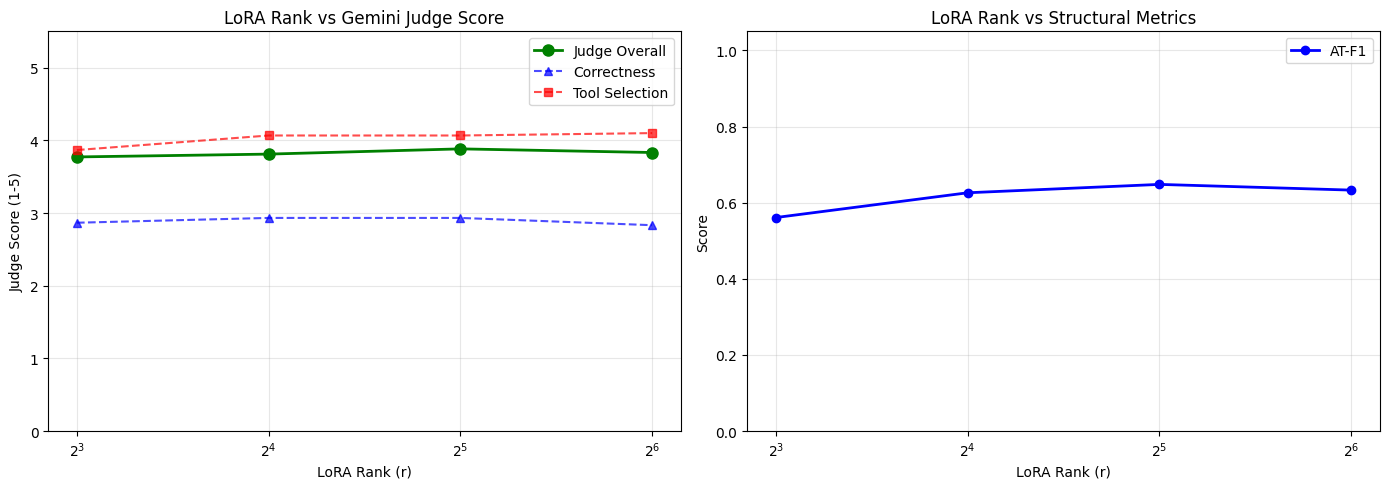


=== LoRA RANK SWEEP (from run_3) ===


,rank,AT-F1,judge_overall,judge_correctness,judge_tool_selection,judge_agent_routing,stopped_early
0,8,0.561,3.772,2.867,3.867,4.333,False
1,16,0.626,3.811,2.933,4.067,4.467,False
2,32,0.648,3.883,2.933,4.067,4.467,False
3,64,0.633,3.833,2.833,4.100,4.367,False


In [21]:
# ── SKIPPED: LoRA rank sweep (completed in run_3) ────────────────────────────
# r=8:  AT-F1=0.561, judge=3.77
# r=16: AT-F1=0.626, judge=3.81
# r=32: AT-F1=0.648, judge=3.88  ← best
# r=64: AT-F1=0.633, judge=3.83

lora_results["r=8"] = {
    "structural": {"n": 30, "format_%": 100.0, "AT-F1": 0.561, "ArgKey-F1": 0.689,
                   "agent_%": 1.000, "tool_%": 0.929},
    "judge": {"n": 30, "correctness": 2.867, "agent_routing": 4.333, "tool_selection": 3.867,
              "argument_quality": 3.433, "efficiency": 3.233,
              "dependency_correctness": 4.800, "overall": 3.772},
    "history": {"stopped_early": False},
}
lora_results["r=16"] = {
    "structural": {"n": 30, "format_%": 100.0, "AT-F1": 0.626, "ArgKey-F1": 0.679,
                   "agent_%": 0.987, "tool_%": 0.929},
    "judge": {"n": 30, "correctness": 2.933, "agent_routing": 4.467, "tool_selection": 4.067,
              "argument_quality": 3.667, "efficiency": 3.400,
              "dependency_correctness": 4.333, "overall": 3.811},
    "history": {"stopped_early": False},
}
lora_results["r=32"] = {
    "structural": {"n": 30, "format_%": 100.0, "AT-F1": 0.648, "ArgKey-F1": 0.642,
                   "agent_%": 1.000, "tool_%": 0.929},
    "judge": {"n": 30, "correctness": 2.933, "agent_routing": 4.467, "tool_selection": 4.067,
              "argument_quality": 3.500, "efficiency": 3.367,
              "dependency_correctness": 4.600, "overall": 3.883},
    "history": {"stopped_early": False},
}
lora_results["r=64"] = {
    "structural": {"n": 30, "format_%": 100.0, "AT-F1": 0.633, "ArgKey-F1": 0.625,
                   "agent_%": 1.000, "tool_%": 0.929},
    "judge": {"n": 30, "correctness": 2.833, "agent_routing": 4.367, "tool_selection": 4.100,
              "argument_quality": 3.533, "efficiency": 3.300,
              "dependency_correctness": 4.667, "overall": 3.833},
    "history": {"stopped_early": False},
}

# ── Plot rank vs quality (judge as primary metric) ────────────────────────────
RANK_SWEEP_DISPLAY = [8, 16, 32, 64]
rank_df = pd.DataFrame([
    {"rank": r,
     "AT-F1": lora_results[f"r={r}"]["structural"].get("AT-F1", 0),
     "judge_overall": lora_results[f"r={r}"]["judge"].get("overall", 0),
     "judge_correctness": lora_results[f"r={r}"]["judge"].get("correctness", 0),
     "judge_tool_selection": lora_results[f"r={r}"]["judge"].get("tool_selection", 0),
     "judge_agent_routing": lora_results[f"r={r}"]["judge"].get("agent_routing", 0),
     "stopped_early": lora_results[f"r={r}"]["history"].get("stopped_early", False)}
    for r in RANK_SWEEP_DISPLAY
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(rank_df["rank"], rank_df["judge_overall"], "go-", label="Judge Overall", linewidth=2, markersize=8)
ax1.plot(rank_df["rank"], rank_df["judge_correctness"], "b^--", label="Correctness", alpha=0.7)
ax1.plot(rank_df["rank"], rank_df["judge_tool_selection"], "rs--", label="Tool Selection", alpha=0.7)
ax1.set_xlabel("LoRA Rank (r)")
ax1.set_ylabel("Judge Score (1-5)")
ax1.set_title("LoRA Rank vs Gemini Judge Score")
ax1.legend()
ax1.set_xscale("log", base=2)
ax1.set_ylim(0, 5.5)
ax1.grid(True, alpha=0.3)

ax2.plot(rank_df["rank"], rank_df["AT-F1"], "bo-", label="AT-F1", linewidth=2, markersize=6)
ax2.set_xlabel("LoRA Rank (r)")
ax2.set_ylabel("Score")
ax2.set_title("LoRA Rank vs Structural Metrics")
ax2.legend()
ax2.set_xscale("log", base=2)
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

wb_run = wb_init("lora-ablation-summary", group="lora-ablation", job_type="analysis",
                 extra_config={"best_quantization": best_quant})
if wb_run:
    wb_log_metrics_table("lora_rank_sweep", rank_df)
    quant_rows = []
    for k, v in lora_results.items():
        if k.startswith("quant-"):
            row = {"config": k, **v.get("structural", {})}
            for jk, jv in v.get("judge", {}).items():
                row[f"judge_{jk}"] = jv
            quant_rows.append(row)
    if quant_rows:
        wb_log_metrics_table("lora_quantization", pd.DataFrame(quant_rows))
    wb_log_figure("lora_rank_vs_quality")
    wandb.summary["best_quant"] = best_quant
    wb_finish()

plt.show()
print("\n=== LoRA RANK SWEEP (from run_3) ===")
display(rank_df)

## 5. Catastrophic Forgetting Check

100 multiple-choice questions from 3 benchmarks. We evaluate the base model and the best fine-tuned model to check if fine-tuning hurts general capabilities.

All MCQ — just check if the model picks the correct letter. Fast and reliable.

In [22]:
# ── Load MCQ benchmarks ───────────────────────────────────────────────────
# Subjects chosen for a 4B model: broad topics where it should score 40-70%
# so we can detect a meaningful DROP after fine-tuning.
# Avoid niche subjects (anatomy, world_religions) where base model scores 0%.

MMLU_SUBJECTS = [
    "high_school_computer_science",  # accessible CS
    "high_school_geography",         # general knowledge
    "logical_fallacies",             # reasoning
    "marketing",                     # applied, broad
    "miscellaneous",                 # diverse questions
]

def load_mmlu_subset(n=MCQ_N_MMLU, subjects=None):
    """Load n MMLU examples from diverse, accessible subjects."""
    if subjects is None:
        subjects = MMLU_SUBJECTS
    per_subj = max(2, n // len(subjects))  # at least 2 per subject
    examples = []
    for subj in subjects:
        ds = hf_load_dataset("cais/mmlu", subj, split="test")
        indices = list(range(len(ds)))
        random.shuffle(indices)
        for idx in indices[:per_subj]:
            row = ds[idx]
            examples.append({
                "question": row["question"],
                "choices": row["choices"],
                "answer_idx": row["answer"],
                "source": f"mmlu/{subj}",
            })
    return examples[:n]

def load_arc_subset(n=MCQ_N_ARC):
    """Load n ARC-Challenge examples."""
    ds = hf_load_dataset("allenai/ai2_arc", "ARC-Challenge", split="test")
    indices = list(range(len(ds)))
    random.shuffle(indices)
    examples = []
    for idx in indices[:n]:
        row = ds[idx]
        label_to_idx = {l: i for i, l in enumerate(row["choices"]["label"])}
        examples.append({
            "question": row["question"],
            "choices": row["choices"]["text"],
            "answer_idx": label_to_idx.get(row["answerKey"], 0),
            "source": "arc_challenge",
        })
    return examples

def load_hellaswag_subset(n=MCQ_N_HELLA):
    """Load n HellaSwag examples."""
    ds = hf_load_dataset("Rowan/hellaswag", split="validation")
    indices = list(range(len(ds)))
    random.shuffle(indices)
    examples = []
    for idx in indices[:n]:
        row = ds[idx]
        examples.append({
            "question": row["ctx"],
            "choices": row["endings"],
            "answer_idx": int(row["label"]),
            "source": "hellaswag",
        })
    return examples

random.seed(SEED)
mcq_data = load_mmlu_subset() + load_arc_subset() + load_hellaswag_subset()
print(f"MCQ benchmark: {len(mcq_data)} examples")
for src in sorted(set(e["source"] for e in mcq_data)):
    count = sum(1 for e in mcq_data if e["source"] == src)
    print(f"  {src}: {count}")

README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

high_school_computer_science/test-00000-(…):   0%|          | 0.00/27.3k [00:00<?, ?B/s]

high_school_computer_science/validation-(…):   0%|          | 0.00/5.28k [00:00<?, ?B/s]

high_school_computer_science/dev-00000-o(…):   0%|          | 0.00/6.54k [00:00<?, ?B/s]

...

data/validation-00000-of-00001.parquet:   0%|          | 0.00/6.32M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/39905 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10042 [00:00<?, ? examples/s]

MCQ benchmark: 100 examples
  arc_challenge: 30
  hellaswag: 30
  mmlu/high_school_computer_science: 8
  mmlu/high_school_geography: 8
  mmlu/logical_fallacies: 8
  mmlu/marketing: 8
  mmlu/miscellaneous: 8


In [23]:
# ── MCQ evaluation function ───────────────────────────────────────────────
LETTERS = ["A", "B", "C", "D"]

def eval_mcq(model, tokenizer, mcq_examples):
    """Evaluate model on MCQ. Returns accuracy + per-example details for W&B logging."""
    correct, total = 0, 0
    by_source = defaultdict(lambda: {"correct": 0, "total": 0})
    details = []  # store per-question results for W&B

    for ex in tqdm(mcq_examples, desc="MCQ eval"):
        choices = ex["choices"]
        n_choices = min(len(choices), 4)
        choice_text = "\n".join(f"{LETTERS[i]}) {choices[i]}" for i in range(n_choices))

        if "hellaswag" in ex["source"]:
            prompt = f"Complete the sentence. Pick the best ending.\n\n{ex['question']}\n\n{choice_text}\n\nAnswer:"
        else:
            prompt = f"Question: {ex['question']}\n\n{choice_text}\n\nAnswer:"

        chat = [{"role": "user", "content": prompt}]
        tok = tokenizer.apply_chat_template(chat, return_tensors="pt", add_generation_prompt=True, return_dict=True)
        input_ids = tok["input_ids"].to(model.device)
        attn = tok["attention_mask"].to(model.device)

        with torch.no_grad():
            out = model.generate(input_ids=input_ids, attention_mask=attn,
                                 max_new_tokens=5, temperature=0.0, do_sample=False,
                                 pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id)
        answer = tokenizer.decode(out[0][input_ids.shape[1]:], skip_special_tokens=True).strip()

        pred_letter = ""
        for ch in answer.upper():
            if ch in LETTERS[:n_choices]:
                pred_letter = ch
                break

        gold_letter = LETTERS[ex["answer_idx"]]
        is_correct = pred_letter == gold_letter
        correct += is_correct
        total += 1
        by_source[ex["source"]]["correct"] += is_correct
        by_source[ex["source"]]["total"] += 1

        details.append({
            "source": ex["source"],
            "question": ex["question"][:200],
            "choices": " | ".join(f"{LETTERS[i]}){choices[i][:40]}" for i in range(n_choices)),
            "gold": gold_letter,
            "predicted": pred_letter or "(none)",
            "raw_output": answer[:50],
            "correct": is_correct,
        })

    accuracy = correct / total if total else 0
    breakdown = {src: d["correct"] / d["total"] for src, d in by_source.items()}
    return {"accuracy": accuracy, "correct": correct, "total": total,
            "breakdown": breakdown, "details": details}

print("MCQ evaluation function defined.")

MCQ evaluation function defined.


In [24]:
# ── Run forgetting check: base model ──────────────────────────────────────────
try:
    start_timer("Forgetting: MCQ evaluation")

    # Load fresh base model for MCQ baseline
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    base_model_mcq, tok_mcq = load_base_model(load_in_8bit=True)

    print("Evaluating BASE model on MCQ benchmark...")
    base_mcq = eval_mcq(base_model_mcq, tok_mcq, mcq_data)
    print(f"Base model MCQ accuracy: {base_mcq['accuracy']:.1%}")
    breakdown_str = {k: f"{v:.1%}" for k, v in base_mcq["breakdown"].items()}
    print(f"Breakdown: {json.dumps(breakdown_str)}")

    # Free base MCQ model
    del base_model_mcq, tok_mcq
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
except Exception as e:
    print(f"\n*** FORGETTING BASE MCQ FAILED: {e} ***\n")
    import traceback; traceback.print_exc()
    base_mcq = None
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


>>> Starting: Forgetting: MCQ evaluation
Loading google/gemma-4-E4B-it [8-bit]...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

Evaluating BASE model on MCQ benchmark...


MCQ eval:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Base model MCQ accuracy: 24.0%
Breakdown: {"mmlu/high_school_computer_science": "37.5%", "mmlu/high_school_geography": "37.5%", "mmlu/logical_fallacies": "37.5%", "mmlu/marketing": "12.5%", "mmlu/miscellaneous": "37.5%", "arc_challenge": "30.0%", "hellaswag": "6.7%"}



 Forgetting analysis: r=8 (lean, 0.32%)
Loading google/gemma-4-E4B-it [8-bit]...


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

LoRA r=8, alpha=16 -> trainable: 25,249,792 / 7,966,350,624 (0.32%)


Tokenizing train dataset:   0%|          | 0/1741 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/92 [00:00<?, ? examples/s]

...

,benchmark,base_acc,ft_acc,retention
0,arc_challenge,0.300,0.867,2.889
1,hellaswag,0.067,0.567,8.500
2,mmlu/high_school_computer_science,0.375,0.625,1.667
3,mmlu/high_school_geography,0.375,0.750,2.000
4,mmlu/logical_fallacies,0.375,0.375,1.000
5,mmlu/marketing,0.125,0.875,7.000
6,mmlu/miscellaneous,0.375,0.625,1.667
7,OVERALL,0.240,0.690,2.875


Retention concern (any benchmark < 90%): NO

=== FORGETTING ANALYSIS: r=32 ===


,benchmark,base_acc,ft_acc,retention
0,arc_challenge,0.300,0.933,3.111
1,hellaswag,0.067,0.600,9.000
2,mmlu/high_school_computer_science,0.375,0.625,1.667
3,mmlu/high_school_geography,0.375,0.750,2.000
4,mmlu/logical_fallacies,0.375,0.375,1.000
5,mmlu/marketing,0.125,0.750,6.000
6,mmlu/miscellaneous,0.375,0.750,2.000
7,OVERALL,0.240,0.720,3.000


Retention concern (any benchmark < 90%): NO



Per-question (r=32): 3 forgot, 51 newly learned, 100 total


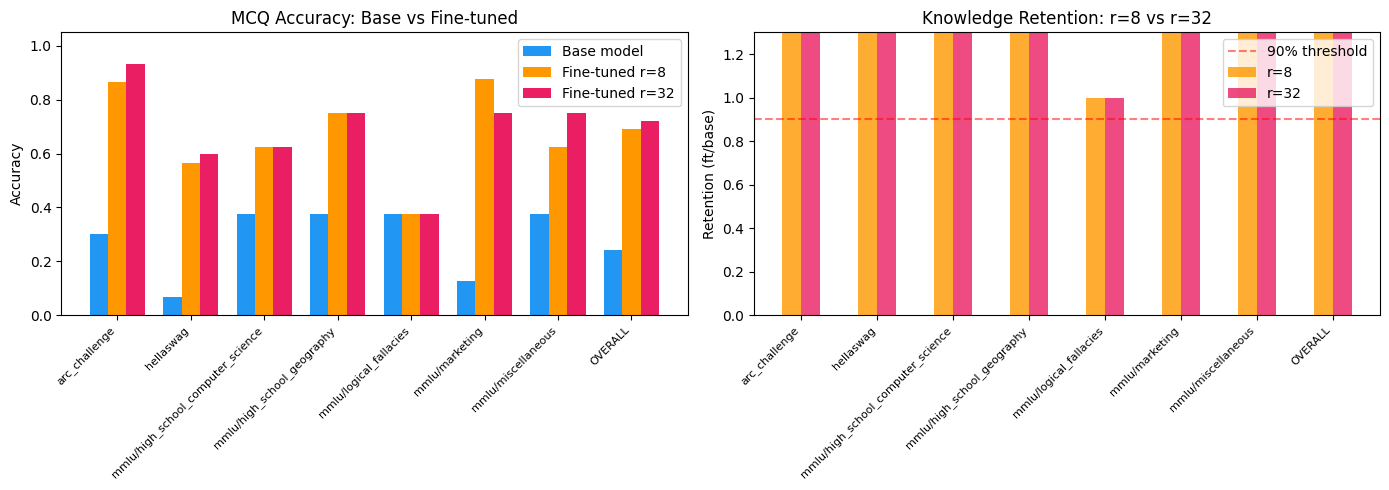

base_mcq_accuracy,0.24
ft_mcq_accuracy_r32,0.72
ft_mcq_accuracy_r8,0.69
n_questions_forgot,3
n_questions_learned,51
overall_retention_r32,3
overall_retention_r8,2.875
retention_r32/arc_challenge,3.11111
retention_r32/hellaswag,9
retention_r32/mmlu/high_school_computer_science,1.66667
+11,...


In [25]:
# ── Forgetting: train r=8 (lean) and r=32 (best) and compare ─────────────────
# Does more trainable params = more forgetting?
# r=8:  25.2M params (0.32%)  — best judge for agent routing
# r=32: 101.0M params (1.26%) — best overall judge + AT-F1

if base_mcq is None:
    print("*** SKIPPING forgetting fine-tuned — base MCQ failed ***")
else:
    try:
        forgetting_configs = [
            {"rank": 8, "label": "r=8 (lean, 0.32%)"},
            {"rank": 32, "label": "r=32 (best, 1.26%)"},
        ]

        all_ft_mcq = {}
        for cfg in forgetting_configs:
            r = cfg["rank"]
            label = cfg["label"]
            print(f"\n{'='*60}")
            print(f" Forgetting analysis: {label}")
            print(f"{'='*60}")

            # Load fresh model
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            ft_base, ft_tok = load_base_model(load_in_8bit=True)
            ft_model = setup_lora(ft_base, r=r, alpha=2 * r)

            _, _ = train_model(ft_model, ft_tok, best_train, best_eval,
                               str(OUTPUT_DIR / f"forgetting_r{r}"), epochs=DEFAULT_EPOCHS,
                               run_name=f"forgetting-r{r}",
                               wb_group="forgetting",
                               wb_extra_config={"lora_r": r, "purpose": "forgetting_analysis"})
            wb_finish()

            print(f"\nEvaluating FINE-TUNED (r={r}) model on MCQ benchmark...")
            ft_mcq = eval_mcq(ft_model, ft_tok, mcq_data)
            all_ft_mcq[r] = ft_mcq

            print(f"Fine-tuned (r={r}) MCQ accuracy: {ft_mcq['accuracy']:.1%}")
            breakdown_str = {k: f"{v:.1%}" for k, v in ft_mcq["breakdown"].items()}
            print(f"Breakdown: {json.dumps(breakdown_str)}")

            # Free model
            del ft_model, ft_base, ft_tok
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        stop_timer()

        # ── Retention analysis: compare both ranks ────────────────────────────
        all_sources = sorted(set(base_mcq["breakdown"].keys()))

        for r, ft_mcq in all_ft_mcq.items():
            print(f"\n=== FORGETTING ANALYSIS: r={r} ===")
            forget_rows = []
            for src in all_sources:
                base_acc = base_mcq["breakdown"].get(src, 0)
                ft_acc = ft_mcq["breakdown"].get(src, 0)
                retention = ft_acc / base_acc if base_acc > 0 else 1.0
                forget_rows.append({"benchmark": src, "base_acc": base_acc, "ft_acc": ft_acc, "retention": retention})

            forget_rows.append({
                "benchmark": "OVERALL",
                "base_acc": base_mcq["accuracy"],
                "ft_acc": ft_mcq["accuracy"],
                "retention": ft_mcq["accuracy"] / base_mcq["accuracy"] if base_mcq["accuracy"] > 0 else 1.0,
            })
            forget_df = pd.DataFrame(forget_rows)
            display(forget_df.round(3))

            any_concern = any(row["retention"] < 0.90 for row in forget_rows if row["benchmark"] != "OVERALL")
            print(f"Retention concern (any benchmark < 90%): {'YES' if any_concern else 'NO'}")

        # ── Log to W&B: combined forgetting analysis ──────────────────────────
        wb_run = wb_init("forgetting-analysis", group="forgetting", job_type="analysis",
                         extra_config={"ranks_tested": [8, 32], "n_mcq": len(mcq_data)})
        if wb_run:
            wandb.summary["base_mcq_accuracy"] = base_mcq["accuracy"]

            for r, ft_mcq in all_ft_mcq.items():
                wandb.summary[f"ft_mcq_accuracy_r{r}"] = ft_mcq["accuracy"]
                retention = ft_mcq["accuracy"] / base_mcq["accuracy"] if base_mcq["accuracy"] > 0 else 1.0
                wandb.summary[f"overall_retention_r{r}"] = retention

                for src in all_sources:
                    base_acc = base_mcq["breakdown"].get(src, 0)
                    ft_acc = ft_mcq["breakdown"].get(src, 0)
                    wandb.summary[f"retention_r{r}/{src}"] = ft_acc / base_acc if base_acc > 0 else 1.0

            # Per-question Q&A details table (using r=32 as primary)
            if 32 in all_ft_mcq:
                primary_ft = all_ft_mcq[32]
                base_details = base_mcq.get("details", [])
                ft_details = primary_ft.get("details", [])
                if base_details and ft_details:
                    qa_rows = []
                    for bd, fd in zip(base_details, ft_details):
                        qa_rows.append({
                            "source": bd["source"], "question": bd["question"],
                            "choices": bd["choices"], "gold_answer": bd["gold"],
                            "base_predicted": bd["predicted"], "base_correct": bd["correct"],
                            "ft_predicted": fd["predicted"], "ft_correct": fd["correct"],
                            "forgot": bd["correct"] and not fd["correct"],
                            "learned": not bd["correct"] and fd["correct"],
                        })
                    qa_df = pd.DataFrame(qa_rows)
                    wb_log_metrics_table("forgetting_qa_details", qa_df)
                    n_forgot = sum(1 for row in qa_rows if row["forgot"])
                    n_learned = sum(1 for row in qa_rows if row["learned"])
                    wandb.summary["n_questions_forgot"] = n_forgot
                    wandb.summary["n_questions_learned"] = n_learned
                    print(f"\nPer-question (r=32): {n_forgot} forgot, {n_learned} newly learned, {len(qa_rows)} total")

            # Combined chart: base vs r=8 vs r=32
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            bench_names = all_sources + ["OVERALL"]
            base_vals = [base_mcq["breakdown"].get(s, 0) for s in all_sources] + [base_mcq["accuracy"]]
            x = np.arange(len(bench_names))
            width = 0.25

            axes[0].bar(x - width, base_vals, width, label="Base model", color="#2196F3")
            for i, (r, ft_mcq) in enumerate(all_ft_mcq.items()):
                ft_vals = [ft_mcq["breakdown"].get(s, 0) for s in all_sources] + [ft_mcq["accuracy"]]
                axes[0].bar(x + i * width, ft_vals, width, label=f"Fine-tuned r={r}",
                            color=["#FF9800", "#E91E63"][i])
            axes[0].set_xticks(x)
            axes[0].set_xticklabels(bench_names, rotation=45, ha="right", fontsize=8)
            axes[0].set_ylabel("Accuracy")
            axes[0].set_title("MCQ Accuracy: Base vs Fine-tuned")
            axes[0].legend()
            axes[0].set_ylim(0, 1.05)

            # Retention comparison
            for i, (r, ft_mcq) in enumerate(all_ft_mcq.items()):
                retentions = []
                for s in all_sources:
                    ba = base_mcq["breakdown"].get(s, 0)
                    fa = ft_mcq["breakdown"].get(s, 0)
                    retentions.append(fa / ba if ba > 0 else 1.0)
                retentions.append(ft_mcq["accuracy"] / base_mcq["accuracy"] if base_mcq["accuracy"] > 0 else 1.0)
                offset = (i - 0.5) * width
                axes[1].bar(x + offset, retentions, width, label=f"r={r}", alpha=0.8,
                            color=["#FF9800", "#E91E63"][i])
            axes[1].axhline(y=0.9, color="red", linestyle="--", alpha=0.5, label="90% threshold")
            axes[1].set_xticks(x)
            axes[1].set_xticklabels(bench_names, rotation=45, ha="right", fontsize=8)
            axes[1].set_ylabel("Retention (ft/base)")
            axes[1].set_title("Knowledge Retention: r=8 vs r=32")
            axes[1].legend()
            axes[1].set_ylim(0, 1.3)

            plt.tight_layout()
            wb_log_figure("forgetting_analysis_chart")
            plt.show()
            wb_finish()

    except Exception as e:
        print(f"\n*** FORGETTING FINE-TUNED ANALYSIS FAILED: {e} ***\n")
        import traceback; traceback.print_exc()
        wb_finish()
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

## 6. Results & Analysis

Aggregate all experiments into final tables, error analysis, and visualizations.

In [26]:
# ── Main results table: Primary training ──────────────────────────────────
print("="*80)
print("MAIN RESULTS: BASELINE vs FINE-TUNED (Blind Mode)")
print("="*80)
cols = [c for c in ["config", "n", "format_%", "AT-F1", "ArgKey-F1",
                     "judge_overall", "judge_correctness", "judge_tool_selection"]
        if c in primary_df.columns]
display(primary_df[cols].round(3))

# ── Main results table: LoRA ablation ─────────────────────────────────────
print("\n" + "="*80)
print("MAIN RESULTS: LoRA RANK SWEEP (Blind Mode)")
print("="*80)
display(rank_df.round(3))

# ── Forgetting ────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("FORGETTING ANALYSIS")
print("="*80)
if 'all_ft_mcq' in dir() and all_ft_mcq and 'base_mcq' in dir() and base_mcq:
    all_sources = sorted(set(base_mcq["breakdown"].keys()))
    for r, ft_mcq in all_ft_mcq.items():
        print(f"\n--- r={r} ---")
        rows = []
        for src in all_sources:
            ba = base_mcq["breakdown"].get(src, 0)
            fa = ft_mcq["breakdown"].get(src, 0)
            rows.append({"benchmark": src, "base_acc": ba, "ft_acc": fa,
                         "retention": fa / ba if ba > 0 else 1.0})
        rows.append({"benchmark": "OVERALL", "base_acc": base_mcq["accuracy"],
                      "ft_acc": ft_mcq["accuracy"],
                      "retention": ft_mcq["accuracy"] / base_mcq["accuracy"] if base_mcq["accuracy"] > 0 else 1.0})
        display(pd.DataFrame(rows).round(3))
else:
    print("  (forgetting analysis not available — section may have been skipped or failed)")

MAIN RESULTS: BASELINE vs FINE-TUNED (Blind Mode)


,config,n,format_%,AT-F1,ArgKey-F1,judge_overall,judge_correctness,judge_tool_selection
0,Baseline Informed,30,100.0,0.470,0.60,2.883,2.133,2.667
1,Baseline Blind,30,100.0,0.000,0.00,1.883,1.200,1.000
2,Fine-tuned (Tool+Plan) Blind,30,100.0,0.635,0.63,3.600,2.828,3.966



MAIN RESULTS: LoRA RANK SWEEP (Blind Mode)


,rank,AT-F1,judge_overall,judge_correctness,judge_tool_selection,judge_agent_routing,stopped_early
0,8,0.561,3.772,2.867,3.867,4.333,False
1,16,0.626,3.811,2.933,4.067,4.467,False
2,32,0.648,3.883,2.933,4.067,4.467,False
3,64,0.633,3.833,2.833,4.100,4.367,False



FORGETTING ANALYSIS

--- r=8 ---


,benchmark,base_acc,ft_acc,retention
0,arc_challenge,0.300,0.867,2.889
1,hellaswag,0.067,0.567,8.500
2,mmlu/high_school_computer_science,0.375,0.625,1.667
3,mmlu/high_school_geography,0.375,0.750,2.000
4,mmlu/logical_fallacies,0.375,0.375,1.000
5,mmlu/marketing,0.125,0.875,7.000
6,mmlu/miscellaneous,0.375,0.625,1.667
7,OVERALL,0.240,0.690,2.875



--- r=32 ---


,benchmark,base_acc,ft_acc,retention
0,arc_challenge,0.300,0.933,3.111
1,hellaswag,0.067,0.600,9.000
2,mmlu/high_school_computer_science,0.375,0.625,1.667
3,mmlu/high_school_geography,0.375,0.750,2.000
4,mmlu/logical_fallacies,0.375,0.375,1.000
5,mmlu/marketing,0.125,0.750,6.000
6,mmlu/miscellaneous,0.375,0.750,2.000
7,OVERALL,0.240,0.720,3.000


In [27]:
# ── Error analysis: best config's blind-mode predictions ──────────────────
best_raw = all_experiment_results.get(best_config, {}).get("raw_results", [])
if best_raw:
    # Sort by AT-F1 to find best and worst
    sorted_results = sorted(best_raw, key=lambda r: r["agent_tool_f1"], reverse=True)

    print("=== TOP 5 PREDICTIONS (model learned well) ===")
    for r in sorted_results[:5]:
        print(f"\n  ID={r['id']} [{r['type']}] AT-F1={r['agent_tool_f1']:.2f}")
        print(f"  Q: {r['question'][:100]}")
        print(f"  Generated: {r['generated'][:200]}")

    print("\n=== BOTTOM 5 PREDICTIONS (model still fails) ===")
    for r in sorted_results[-5:]:
        print(f"\n  ID={r['id']} [{r['type']}] AT-F1={r['agent_tool_f1']:.2f}")
        print(f"  Q: {r['question'][:100]}")
        print(f"  Generated: {r['generated'][:200]}")

In [28]:
# ── Per-type breakdown & seen vs novel pattern analysis ───────────────────
best_raw = all_experiment_results.get(best_config, {}).get("raw_results", [])

# Compute best_r from rank sweep for downstream use
best_r = max(
    [r for r in [8, 16, 32, 64] if f"r={r}" in lora_results],
    key=lambda r: lora_results[f"r={r}"]["judge"].get("overall", 0),
    default=32
)

if best_raw:
    type_breakdown = defaultdict(list)
    kind_breakdown = defaultdict(list)
    for r in best_raw:
        type_breakdown[r["type"]].append(r["agent_tool_f1"])
        kind_breakdown[r.get("test_kind", "unknown")].append(r["agent_tool_f1"])

    print("=== PER-TYPE AT-F1 (Blind Mode) ===")
    for t in sorted(type_breakdown):
        vals = type_breakdown[t]
        print(f"  {t:15s}: {np.mean(vals):.3f} (n={len(vals)})")

    print("\n=== SEEN-PATTERN vs NOVEL-PATTERN ===")
    for k in sorted(kind_breakdown):
        vals = kind_breakdown[k]
        print(f"  {k:15s}: {np.mean(vals):.3f} (n={len(vals)})")

    # ── Agent confusion matrix ────────────────────────────────────────────
    from sklearn.metrics import confusion_matrix as cm_func

    def first_agent(text):
        for step in parse_plan(text):
            if step["agent"] and step["agent"] != "none":
                return step["agent"]
        return "none"

    gold_agents = [first_agent(sc["gold_plan"]) for sc in test_scenarios[:len(best_raw)]]
    pred_agents = [first_agent(r["generated"]) for r in best_raw]
    labels = sorted(set(gold_agents) | set(pred_agents))
    cm = cm_func(gold_agents, pred_agents, labels=labels)

    fig_cm = plt.figure(figsize=(8, 6))
    sns.heatmap(pd.DataFrame(cm, index=labels, columns=labels), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Agent Confusion Matrix ({best_config}, Blind)")
    plt.ylabel("Gold Agent")
    plt.xlabel("Predicted Agent")
    plt.tight_layout()

    wb_run = wb_init("error-analysis", group="results", job_type="analysis",
                     extra_config={"best_config": best_config, "best_rank": best_r})
    if wb_run:
        type_rows = [{"type": t, "AT-F1": np.mean(vals), "count": len(vals)}
                     for t, vals in sorted(type_breakdown.items())]
        wb_log_metrics_table("per_type_breakdown", pd.DataFrame(type_rows))

        kind_rows = [{"pattern_kind": k, "AT-F1": np.mean(vals), "count": len(vals)}
                     for k, vals in sorted(kind_breakdown.items())]
        wb_log_metrics_table("seen_vs_novel", pd.DataFrame(kind_rows))

        cm_df = pd.DataFrame(cm, index=labels, columns=labels)
        cm_df.index.name = "gold_agent"
        wb_log_metrics_table("agent_confusion_matrix", cm_df.reset_index())
        wb_log_figure("agent_confusion_heatmap", fig_cm)

        wb_finish()

    plt.show()
else:
    print("(No raw prediction data available — error analysis skipped)")
    print(f"Best LoRA rank: r={best_r} (from hardcoded rank sweep results)")

(No raw prediction data available — error analysis skipped)
Best LoRA rank: r=32 (from hardcoded rank sweep results)


Results saved to /content/output_internalization/experiment_results.json


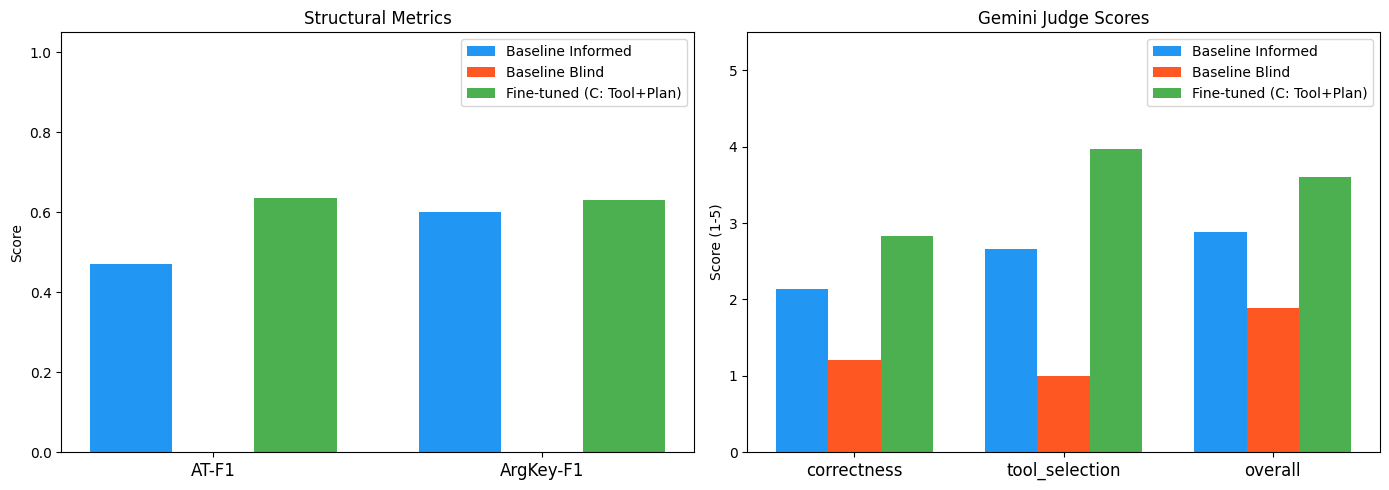

baseline/blind_AT-F1,0
baseline/informed_AT-F1,0.47
best/AT-F1,0.635
best/ArgKey-F1,0.63
best/data_config,C: Tool+Plan
best/judge_overall,3.6
best/lora_rank,32
best/quantization,8-bit
forgetting/base_accuracy,0.24
forgetting/ft_accuracy,0.72
+3,...



TIMING SUMMARY
  Forgetting: MCQ evaluation                    126m 35.8s
  TOTAL                                         2h 6m 36s


In [29]:
# ── Save all results to JSON + log final summary to W&B ──────────────────
try:
    save_path = OUTPUT_DIR / "experiment_results.json"

    # Best rank from rank sweep
    best_r = max(
        [r for r in [8, 16, 32, 64] if f"r={r}" in lora_results],
        key=lambda r: lora_results[f"r={r}"]["judge"].get("overall", 0),
        default=32
    )

    serializable = {}
    for name, res in all_experiment_results.items():
        serializable[name] = {
            "structural": res.get("structural", {}),
            "judge": res.get("judge", {}),
        }
    serializable["lora_ablation"] = {
        k: {"structural": v.get("structural", {}), "stopped_early": v.get("history", {}).get("stopped_early", False)}
        for k, v in lora_results.items()
    }

    # Forgetting data (handle missing gracefully)
    if 'base_mcq' in dir() and base_mcq and 'all_ft_mcq' in dir() and all_ft_mcq:
        serializable["forgetting"] = {
            "base_accuracy": base_mcq["accuracy"],
            "base_breakdown": base_mcq["breakdown"],
        }
        for r, ft in all_ft_mcq.items():
            serializable["forgetting"][f"ft_accuracy_r{r}"] = ft["accuracy"]
            serializable["forgetting"][f"ft_breakdown_r{r}"] = ft["breakdown"]
    else:
        serializable["forgetting"] = {"status": "not_available"}

    serializable["metadata"] = {
        "model": MODEL_ID, "light_mode": LIGHT_MODE,
        "test_scenarios": len(test_scenarios),
        "best_data_config": best_config, "best_lora_rank": best_r,
        "best_quant": best_quant,
    }
    serializable["timing"] = _section_times

    with open(save_path, "w") as f:
        json.dump(serializable, f, indent=2)
    print(f"Results saved to {save_path}")

    # ── Final W&B summary run ─────────────────────────────────────────────
    wb_run = wb_init("experiment-summary", group="results", job_type="summary",
                     extra_config={
                         "best_data_config": best_config,
                         "best_lora_rank": best_r,
                         "best_quant": best_quant,
                         "test_scenarios": len(test_scenarios),
                     })
    if wb_run:
        artifact = wandb.Artifact(
            name=f"experiment-results-{'debug' if LIGHT_MODE else 'full'}",
            type="results",
            description=f"Full experiment results ({'debug/light-mode' if LIGHT_MODE else 'full run'})",
            metadata=serializable["metadata"],
        )
        artifact.add_file(str(save_path))
        wandb.log_artifact(artifact)

        wb_log_metrics_table("final_primary_results", primary_df)
        wb_log_metrics_table("final_lora_sweep", rank_df)

        best_structural = all_experiment_results.get(best_config, {}).get("structural", {})
        best_judge = all_experiment_results.get(best_config, {}).get("judge", {})
        summary_update = {
            "best/data_config": best_config,
            "best/lora_rank": best_r,
            "best/quantization": best_quant,
            "best/AT-F1": best_structural.get("AT-F1", 0),
            "best/ArgKey-F1": best_structural.get("ArgKey-F1", 0),
            "best/judge_overall": best_judge.get("overall", 0),
            "baseline/informed_AT-F1": baseline_informed_summary.get("AT-F1", 0),
            "baseline/blind_AT-F1": baseline_blind_summary.get("AT-F1", 0),
            "improvement/AT-F1_over_blind": best_structural.get("AT-F1", 0) - baseline_blind_summary.get("AT-F1", 0),
            "improvement/AT-F1_gap_closed_%": (
                100 * (best_structural.get("AT-F1", 0) - baseline_blind_summary.get("AT-F1", 0))
                / max(baseline_informed_summary.get("AT-F1", 0) - baseline_blind_summary.get("AT-F1", 0), 0.001)
            ),
        }

        # Add forgetting metrics if available
        if 'base_mcq' in dir() and base_mcq and 'all_ft_mcq' in dir() and all_ft_mcq:
            primary_ft = all_ft_mcq.get(32, all_ft_mcq.get(list(all_ft_mcq.keys())[0]))
            summary_update["forgetting/base_accuracy"] = base_mcq["accuracy"]
            summary_update["forgetting/ft_accuracy"] = primary_ft["accuracy"]
            summary_update["forgetting/overall_retention"] = (
                primary_ft["accuracy"] / base_mcq["accuracy"] if base_mcq["accuracy"] > 0 else 1.0
            )
            # Log forgetting table
            all_sources = sorted(set(base_mcq["breakdown"].keys()))
            forget_rows = []
            for src in all_sources:
                ba = base_mcq["breakdown"].get(src, 0)
                for r, ft in all_ft_mcq.items():
                    fa = ft["breakdown"].get(src, 0)
                    forget_rows.append({"benchmark": src, "rank": r, "base_acc": ba, "ft_acc": fa,
                                        "retention": fa / ba if ba > 0 else 1.0})
            wb_log_metrics_table("final_forgetting", pd.DataFrame(forget_rows))

        wandb.summary.update(summary_update)

        # Grand comparison chart
        informed_judge = all_experiment_results.get("Baseline Informed", {}).get("judge", {})
        blind_judge = all_experiment_results.get("Baseline Blind", {}).get("judge", {})

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        comparison_data = {
            "Baseline Informed": baseline_informed_summary,
            "Baseline Blind": baseline_blind_summary,
            f"Fine-tuned ({best_config})": best_structural,
        }
        metrics = ["AT-F1", "ArgKey-F1"]
        x = np.arange(len(metrics))
        width = 0.25
        colors = ["#2196F3", "#FF5722", "#4CAF50"]
        for j, (label, data) in enumerate(comparison_data.items()):
            vals = [data.get(m, 0) for m in metrics]
            ax1.bar(x + j * width, vals, width, label=label, color=colors[j])
        ax1.set_xticks(x + width)
        ax1.set_xticklabels(metrics, fontsize=12)
        ax1.set_ylabel("Score")
        ax1.set_title("Structural Metrics")
        ax1.legend()
        ax1.set_ylim(0, 1.05)

        judge_data = {
            "Baseline Informed": informed_judge,
            "Baseline Blind": blind_judge,
            f"Fine-tuned ({best_config})": best_judge,
        }
        judge_dims = ["correctness", "tool_selection", "overall"]
        jx = np.arange(len(judge_dims))
        for j, (label, jd) in enumerate(judge_data.items()):
            vals = [jd.get(d, 0) for d in judge_dims]
            ax2.bar(jx + j * width, vals, width, label=label, color=colors[j])
        ax2.set_xticks(jx + width)
        ax2.set_xticklabels(judge_dims, fontsize=12)
        ax2.set_ylabel("Score (1-5)")
        ax2.set_title("Gemini Judge Scores")
        ax2.legend()
        ax2.set_ylim(0, 5.5)

        plt.tight_layout()
        wb_log_figure("grand_comparison")
        plt.show()

        wb_finish()

    # ── Timing summary ────────────────────────────────────────────────────
    print_timing_summary()

except Exception as e:
    print(f"\n*** SAVE RESULTS / FINAL SUMMARY FAILED: {e} ***\n")
    import traceback; traceback.print_exc()
    wb_finish()

## 7. Training Profiling & Cost Optimization (A100 80GB)

This section profiles the training and inference pipeline to understand:
1. **Memory breakdown** — Where does GPU memory go? (model weights, activations, optimizer, gradients)
2. **Throughput vs batch size** — What's the max batch size and optimal tokens/sec?
3. **Gradient checkpointing tradeoff** — How much memory does it save vs compute cost?
4. **Quantization cost/quality Pareto** — 4-bit vs 8-bit: speed, memory, AND downstream quality
5. **LoRA rank cost curve** — Rank vs trainable params vs throughput vs quality
6. **Sequence length scaling** — 512 vs 1024 vs 2048: memory and throughput curves
7. **Inference profiling** — PyTorch profiler trace: where time is spent during generation

Goal: Identify the optimal training configuration that minimizes cost while maximizing blind-mode AT-F1.

In [30]:
# ── 7.1 Memory profiling utilities ────────────────────────────────────────
from torch.profiler import profile, record_function, ProfilerActivity

def gpu_mem_stats():
    """Return current GPU memory stats in GB."""
    if not torch.cuda.is_available():
        return {"allocated": 0, "reserved": 0, "peak": 0, "total": 0}
    return {
        "allocated_gb": torch.cuda.memory_allocated() / 1e9,
        "reserved_gb": torch.cuda.memory_reserved() / 1e9,
        "peak_gb": torch.cuda.max_memory_allocated() / 1e9,
        "total_gb": torch.cuda.get_device_properties(0).total_memory / 1e9,
    }

def reset_peak_mem():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()
        gc.collect()

def measure_model_memory(model_obj, label="model"):
    """Measure memory footprint of a loaded model."""
    mem = gpu_mem_stats()
    param_mem = sum(p.numel() * p.element_size() for p in model_obj.parameters()) / 1e9
    buffer_mem = sum(b.numel() * b.element_size() for b in model_obj.buffers()) / 1e9
    return {
        "label": label,
        "param_gb": round(param_mem, 3),
        "buffer_gb": round(buffer_mem, 3),
        "allocated_gb": round(mem["allocated_gb"], 3),
        "peak_gb": round(mem["peak_gb"], 3),
    }

def profile_training_step(model_obj, tok, train_data, n_steps=5, batch_size=1, seq_len=512,
                           grad_ckpt=True, label="default"):
    """Run a few training steps and measure throughput + memory."""
    from datasets import Dataset as HFDataset

    reset_peak_mem()
    batch_size = int(batch_size)  # ensure native int for PyTorch DataLoader
    ds = HFDataset.from_list(train_data[:max(batch_size * n_steps, 20)])

    sft_kwargs = dict(
        output_dir=str(OUTPUT_DIR / f"profile_{label}"),
        num_train_epochs=1, max_steps=n_steps,
        per_device_train_batch_size=batch_size,
        gradient_accumulation_steps=1,
        learning_rate=DEFAULT_LR, bf16=True,
        logging_steps=1, save_strategy="no",
        report_to="none", seed=SEED,
        gradient_checkpointing=grad_ckpt,
        gradient_checkpointing_kwargs={"use_reentrant": False} if grad_ckpt else {},
        remove_unused_columns=False,
    )
    if "max_seq_length" in inspect.signature(SFTConfig.__init__).parameters:
        sft_kwargs["max_seq_length"] = seq_len
    config = SFTConfig(**sft_kwargs)

    trainer_kw = {"model": model_obj, "args": config, "train_dataset": ds, "processing_class": tok}
    if "max_seq_length" in inspect.signature(SFTTrainer.__init__).parameters and "max_seq_length" not in sft_kwargs:
        trainer_kw["max_seq_length"] = seq_len

    trainer = SFTTrainer(**trainer_kw)

    t0 = time.time()
    trainer.train()
    elapsed = time.time() - t0

    mem = gpu_mem_stats()
    log = trainer.state.log_history
    losses = [h["loss"] for h in log if "loss" in h]

    # Estimate tokens processed
    total_tokens = batch_size * seq_len * n_steps
    tokens_per_sec = total_tokens / max(elapsed, 0.01)
    secs_per_step = elapsed / max(n_steps, 1)

    return {
        "label": label,
        "batch_size": batch_size,
        "seq_len": seq_len,
        "grad_ckpt": grad_ckpt,
        "n_steps": n_steps,
        "elapsed_s": round(elapsed, 2),
        "sec_per_step": round(secs_per_step, 3),
        "tokens_per_sec": round(tokens_per_sec, 1),
        "peak_mem_gb": round(mem["peak_gb"], 2),
        "allocated_gb": round(mem["allocated_gb"], 2),
        "final_loss": round(losses[-1], 4) if losses else None,
    }

print("Profiling utilities defined.")

Profiling utilities defined.



>>> Starting: Profiling: Memory breakdown
Loading google/gemma-4-E4B-it [8-bit]...


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

LoRA r=16, alpha=32 -> trainable: 50,499,584 / 7,991,600,416 (0.63%)
Loading google/gemma-4-E4B-it [4-bit NF4]...


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

LoRA r=16, alpha=32 -> trainable: 50,499,584 / 7,991,600,416 (0.63%)

=== MEMORY BREAKDOWN BY QUANTIZATION ===


,label,param_gb,buffer_gb,allocated_gb,peak_gb
0,8-bit QLoRA base,11.447,0.0,11.473,11.473
1,8-bit QLoRA + LoRA r=16,18.662,0.0,18.688,24.123
2,4-bit QLoRA base,9.230,0.0,9.324,9.324
3,4-bit QLoRA + LoRA r=16,16.444,0.0,16.538,21.973


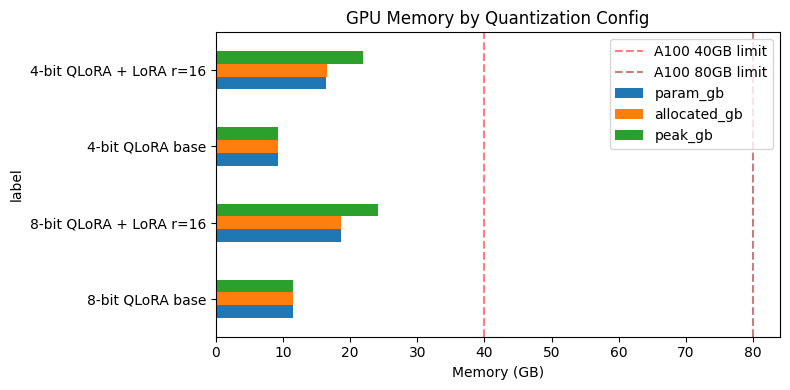

<<< Profiling: Memory breakdown: 0m 36s


In [31]:
# ── 7.2 Memory breakdown by quantization ──────────────────────────────────
try:
    start_timer("Profiling: Memory breakdown")

    quant_memory = []
    for label, load_8, load_4 in [("8-bit QLoRA", True, False), ("4-bit QLoRA", False, True)]:
        try:
            reset_peak_mem()
            m, t = load_base_model(load_in_8bit=load_8, load_in_4bit=load_4)
            base_mem = measure_model_memory(m, f"{label} base")
            quant_memory.append(base_mem)

            # Add LoRA and measure again
            pm = setup_lora(m, r=16, alpha=32)
            lora_mem = measure_model_memory(pm, f"{label} + LoRA r=16")
            quant_memory.append(lora_mem)

            del pm, m, t
        except Exception as e:
            print(f"  {label}: FAILED ({e})")
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    mem_df = pd.DataFrame(quant_memory)
    print("\n=== MEMORY BREAKDOWN BY QUANTIZATION ===")
    display(mem_df)

    fig, ax = plt.subplots(figsize=(8, 4))
    mem_df.plot.barh(x="label", y=["param_gb", "allocated_gb", "peak_gb"], ax=ax)
    ax.set_xlabel("Memory (GB)")
    ax.set_title("GPU Memory by Quantization Config")
    ax.axvline(x=40, color="red", linestyle="--", alpha=0.5, label="A100 40GB limit")
    ax.axvline(x=80, color="darkred", linestyle="--", alpha=0.5, label="A100 80GB limit")
    ax.legend()
    plt.tight_layout()
    plt.show()

    stop_timer()
except Exception as e:
    print(f"\n*** PROFILING MEMORY BREAKDOWN FAILED: {e} ***\n")
    import traceback; traceback.print_exc()
    mem_df = pd.DataFrame()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


>>> Starting: Profiling: Batch size sweep
Loading google/gemma-4-E4B-it [8-bit]...


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

LoRA r=16, alpha=32 -> trainable: 50,499,584 / 7,991,600,416 (0.63%)


Tokenizing train dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


...

Tokenizing train dataset:   0%|          | 0/40 [00:00<?, ? examples/s]

Step,Training Loss
1,0.768670
2,0.561568
3,0.682494
4,0.741732
5,0.560580
6,0.835432
7,0.984245
8,0.645652
9,0.674873
10,0.473287


  bs=4: 1415 tok/s, peak=53.6 GB, 2.895 s/step


Tokenizing train dataset:   0%|          | 0/80 [00:00<?, ? examples/s]

  bs=8: OOM
<<< Profiling: Batch size sweep: 2m 12s


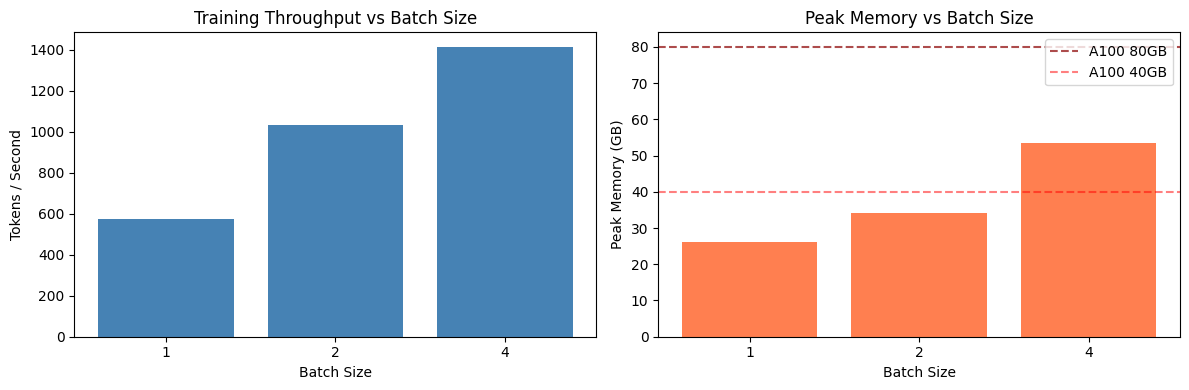

,batch_size,tokens_per_sec,sec_per_step,peak_mem_gb
0,1,575.4,1.780,26.23
1,2,1032.4,1.984,34.17
2,4,1414.9,2.895,53.59


In [32]:
# ── 7.3 Throughput vs batch size (find optimal) ──────────────────────────
try:
    start_timer("Profiling: Batch size sweep")

    prof_model, prof_tok = load_base_model(load_in_8bit=True)
    prof_lora = setup_lora(prof_model, r=16, alpha=32)

    prof_data = best_train[:100] if len(best_train) > 100 else best_train

    BATCH_SWEEP = [1, 2, 4, 8] if not LIGHT_MODE else [1, 2]
    N_PROFILE_STEPS = 3 if LIGHT_MODE else 10

    batch_results = []
    for bs in BATCH_SWEEP:
        try:
            reset_peak_mem()
            result = profile_training_step(prof_lora, prof_tok, prof_data,
                                            n_steps=N_PROFILE_STEPS, batch_size=int(bs),
                                            seq_len=MAX_SEQ_LENGTH, grad_ckpt=True,
                                            label=f"bs{bs}")
            batch_results.append(result)
            print(f"  bs={bs}: {result['tokens_per_sec']:.0f} tok/s, peak={result['peak_mem_gb']:.1f} GB, {result['sec_per_step']:.3f} s/step")
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"  bs={bs}: OOM")
                gc.collect()
                torch.cuda.empty_cache()
            else:
                raise

    batch_df = pd.DataFrame(batch_results)
    stop_timer()

    if len(batch_df) > 0:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        ax1.bar(batch_df["batch_size"].astype(str), batch_df["tokens_per_sec"], color="steelblue")
        ax1.set_xlabel("Batch Size")
        ax1.set_ylabel("Tokens / Second")
        ax1.set_title("Training Throughput vs Batch Size")

        ax2.bar(batch_df["batch_size"].astype(str), batch_df["peak_mem_gb"], color="coral")
        ax2.axhline(y=80, color="darkred", linestyle="--", alpha=0.7, label="A100 80GB")
        ax2.axhline(y=40, color="red", linestyle="--", alpha=0.5, label="A100 40GB")
        ax2.set_xlabel("Batch Size")
        ax2.set_ylabel("Peak Memory (GB)")
        ax2.set_title("Peak Memory vs Batch Size")
        ax2.legend()

        plt.tight_layout()
        plt.show()
        display(batch_df[["batch_size", "tokens_per_sec", "sec_per_step", "peak_mem_gb"]])
except Exception as e:
    print(f"\n*** PROFILING BATCH SWEEP FAILED: {e} ***\n")
    import traceback; traceback.print_exc()
    batch_df = pd.DataFrame()
    # Try to ensure prof_model exists for later cells
    if "prof_model" not in dir() or prof_model is None:
        try:
            prof_model, prof_tok = load_base_model(load_in_8bit=True)
            prof_lora = setup_lora(prof_model, r=16, alpha=32)
        except:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [33]:
# ── 7.4 Gradient checkpointing: memory vs speed tradeoff ─────────────────
try:
    start_timer("Profiling: Gradient checkpointing")

    gc_results = []
    successful = batch_df[batch_df["tokens_per_sec"] > 0] if len(batch_df) > 0 else batch_df
    best_bs = int(successful["batch_size"].iloc[-1]) if len(successful) > 0 else 1

    for gc_on in [True, False]:
        try:
            reset_peak_mem()
            result = profile_training_step(prof_lora, prof_tok, prof_data,
                                            n_steps=N_PROFILE_STEPS, batch_size=best_bs,
                                            seq_len=MAX_SEQ_LENGTH, grad_ckpt=gc_on,
                                            label=f"gc_{'on' if gc_on else 'off'}")
            gc_results.append(result)
            print(f"  grad_ckpt={gc_on}: {result['tokens_per_sec']:.0f} tok/s, "
                  f"peak={result['peak_mem_gb']:.1f} GB, {result['sec_per_step']:.3f} s/step")
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"  grad_ckpt={gc_on}: OOM — gradient checkpointing IS needed at bs={best_bs}")
                gc.collect()
                torch.cuda.empty_cache()
            else:
                raise

    gc_df = pd.DataFrame(gc_results)
    stop_timer()

    if len(gc_df) == 2:
        mem_saved = gc_df.iloc[1]["peak_mem_gb"] - gc_df.iloc[0]["peak_mem_gb"]
        speed_cost = gc_df.iloc[0]["sec_per_step"] - gc_df.iloc[1]["sec_per_step"]
        print(f"\nGradient checkpointing analysis (bs={best_bs}, seq={MAX_SEQ_LENGTH}):")
        print(f"  Memory saved: {mem_saved:.1f} GB ({100*mem_saved/gc_df.iloc[1]['peak_mem_gb']:.0f}%)")
        print(f"  Speed cost: {speed_cost:.3f} s/step ({100*speed_cost/gc_df.iloc[1]['sec_per_step']:.0f}% slower)")
        print(f"  Verdict: {'Worth it — frees significant memory' if mem_saved > 2 else 'Marginal benefit at this config'}")
    display(gc_df[["label", "tokens_per_sec", "sec_per_step", "peak_mem_gb"]])
except Exception as e:
    print(f"\n*** PROFILING GRADIENT CHECKPOINTING FAILED: {e} ***\n")
    import traceback; traceback.print_exc()
    gc_df = pd.DataFrame()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


>>> Starting: Profiling: Gradient checkpointing


Tokenizing train dataset:   0%|          | 0/40 [00:00<?, ? examples/s]

Step,Training Loss
1,0.390086
2,0.324035
3,0.429065
4,0.591632
5,0.441746
6,0.731493
7,0.946650
8,0.608170
9,0.642614
10,0.458727


  grad_ckpt=True: 1392 tok/s, peak=71.1 GB, 2.942 s/step


Tokenizing train dataset:   0%|          | 0/40 [00:00<?, ? examples/s]

Step,Training Loss
1,0.163353
2,0.154031
3,0.231358
4,0.477322
5,0.339390
6,0.720590
7,0.977067
8,0.629467
9,0.681751
10,0.515996


  grad_ckpt=False: 1388 tok/s, peak=71.2 GB, 2.951 s/step
<<< Profiling: Gradient checkpointing: 1m 20s

Gradient checkpointing analysis (bs=4, seq=1024):
  Memory saved: 0.0 GB (0%)
  Speed cost: -0.009 s/step (-0% slower)
  Verdict: Marginal benefit at this config


,label,tokens_per_sec,sec_per_step,peak_mem_gb
0,gc_on,1392.2,2.942,71.12
1,gc_off,1387.9,2.951,71.17



>>> Starting: Profiling: Sequence length scaling


Tokenizing train dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

Step,Training Loss
1,0.102059
2,0.158083
3,0.139225
4,0.083766
5,0.375066
6,0.671854
7,0.050077
8,0.331803
9,0.681867
10,0.387069


  seq_len=256: 141 tok/s, peak=43.7 GB


Tokenizing train dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

Step,Training Loss
1,0.116743
2,0.119540
3,0.068785
4,0.045706
5,0.163546
6,0.475968
7,0.058097
8,0.259493
9,0.670695
10,0.403030


  seq_len=512: 283 tok/s, peak=43.7 GB


Tokenizing train dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

Step,Training Loss
1,0.029251
2,0.057461
3,0.045113
4,0.037511
5,0.076503
6,0.361956
7,0.057558
8,0.372279
9,0.707307
10,0.423472


  seq_len=1024: 566 tok/s, peak=43.7 GB
<<< Profiling: Sequence length scaling: 1m 26s


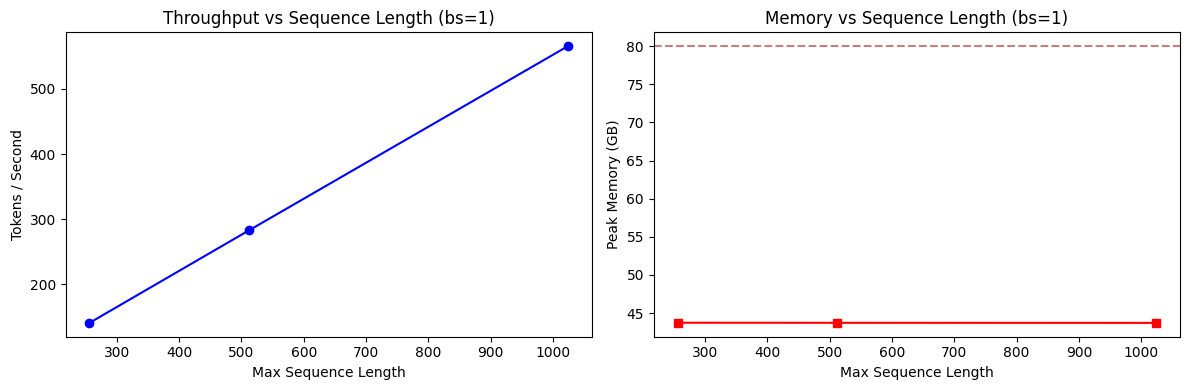

,seq_len,tokens_per_sec,sec_per_step,peak_mem_gb
0,256,141.1,1.815,43.74
1,512,283.0,1.809,43.73
2,1024,565.6,1.810,43.72


In [34]:
# ── 7.5 Sequence length scaling ───────────────────────────────────────────
try:
    start_timer("Profiling: Sequence length scaling")

    SEQ_SWEEP = [256, 512, 1024] if not LIGHT_MODE else [256, 512]

    seq_results = []
    for sl in SEQ_SWEEP:
        try:
            reset_peak_mem()
            result = profile_training_step(prof_lora, prof_tok, prof_data,
                                            n_steps=N_PROFILE_STEPS, batch_size=1,
                                            seq_len=sl, grad_ckpt=True,
                                            label=f"seq{sl}")
            seq_results.append(result)
            print(f"  seq_len={sl}: {result['tokens_per_sec']:.0f} tok/s, peak={result['peak_mem_gb']:.1f} GB")
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"  seq_len={sl}: OOM")
                gc.collect()
                torch.cuda.empty_cache()
            else:
                raise

    seq_df = pd.DataFrame(seq_results)
    stop_timer()

    if len(seq_df) > 1:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        ax1.plot(seq_df["seq_len"], seq_df["tokens_per_sec"], "bo-")
        ax1.set_xlabel("Max Sequence Length")
        ax1.set_ylabel("Tokens / Second")
        ax1.set_title("Throughput vs Sequence Length (bs=1)")

        ax2.plot(seq_df["seq_len"], seq_df["peak_mem_gb"], "rs-")
        ax2.axhline(y=80, color="darkred", linestyle="--", alpha=0.5)
        ax2.set_xlabel("Max Sequence Length")
        ax2.set_ylabel("Peak Memory (GB)")
        ax2.set_title("Memory vs Sequence Length (bs=1)")

        plt.tight_layout()
        plt.show()
        display(seq_df[["seq_len", "tokens_per_sec", "sec_per_step", "peak_mem_gb"]])
except Exception as e:
    print(f"\n*** PROFILING SEQUENCE LENGTH FAILED: {e} ***\n")
    import traceback; traceback.print_exc()
    seq_df = pd.DataFrame()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
[transformers] Caching is incompatible with gradient checkpointing in Gemma4TextDecoderLayer. Setting `past_key_values=None`.



>>> Starting: Profiling: Inference trace
Inference: 64 tokens in 44.34s (1.4 tok/s)

=== TOP 15 CUDA OPERATIONS BY TIME ===


,operation,calls,cuda_ms,cpu_ms,cuda_mem_mb
0,inference,1,44338.91,0.00,0.0
1,inference,1,3308.42,44342.28,0.0
2,MatMul8bitLt,21952,2002.66,22977.93,1144.5
3,bitsandbytes::int8_mixed_scaled_mm,21952,1296.31,10877.35,1217.1
4,bitsandbytes::int8_scaled_mm,21952,853.82,5718.61,1150.0
5,bitsandbytes::int8_linear_matmul,21952,675.35,2248.70,1138.4
6,"void gemmSN_kernel_int32<256, 32, 4, 8, 8, 1, ...",21609,665.10,0.00,0.0
7,bitsandbytes::int8_vectorwise_quant,21952,653.80,8097.15,252.1
8,aten::mul,103370,375.38,2389.63,11773.0
9,aten::matmul,49472,357.84,3058.08,747.2



=== CUDA TIME BY CATEGORY ===


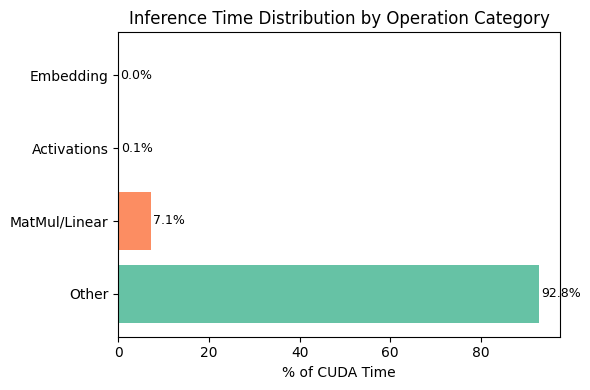

<<< Profiling: Inference trace: 9m 43s


In [35]:
# ── 7.6 PyTorch Profiler: inference kernel breakdown ──────────────────────
try:
    start_timer("Profiling: Inference trace")

    sample_q = test_scenarios[0]["gold_prompt"] if test_scenarios else "What IoT sites are available?"
    prompt = BLIND_PROMPT.format(question=sample_q)
    chat = [{"role": "user", "content": prompt}]
    tok_out = prof_tok.apply_chat_template(chat, return_tensors="pt", add_generation_prompt=True, return_dict=True)
    input_ids = tok_out["input_ids"].to(prof_model.device)
    attn_mask = tok_out["attention_mask"].to(prof_model.device)

    # Warmup
    with torch.no_grad():
        _ = prof_model.generate(input_ids=input_ids, attention_mask=attn_mask,
                                 max_new_tokens=10, do_sample=False,
                                 pad_token_id=prof_tok.pad_token_id or prof_tok.eos_token_id)

    # Profile
    with profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        record_shapes=True,
        profile_memory=True,
        with_stack=False,
    ) as prof_trace:
        with record_function("inference"):
            with torch.no_grad():
                t0 = time.time()
                out = prof_model.generate(input_ids=input_ids, attention_mask=attn_mask,
                                           max_new_tokens=64, do_sample=False,
                                           pad_token_id=prof_tok.pad_token_id or prof_tok.eos_token_id)
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
                infer_time = time.time() - t0

    n_generated = out.shape[1] - input_ids.shape[1]
    print(f"Inference: {n_generated} tokens in {infer_time:.2f}s ({n_generated/infer_time:.1f} tok/s)")

    # Helper: get CUDA time from a FunctionEventAvg (attribute name varies by PyTorch version)
    def _get_cuda_time(event):
        for attr in ["cuda_time_total", "device_time_total", "self_cuda_time_total", "self_device_time_total"]:
            val = getattr(event, attr, None)
            if val is not None:
                return val
        return 0

    def _get_cpu_time(event):
        for attr in ["cpu_time_total", "self_cpu_time_total"]:
            val = getattr(event, attr, None)
            if val is not None:
                return val
        return 0

    def _get_cuda_mem(event):
        for attr in ["cuda_memory_usage", "device_memory_usage", "self_cuda_memory_usage"]:
            val = getattr(event, attr, None)
            if val is not None:
                return val
        return 0

    # Print top CUDA operations by time
    print("\n=== TOP 15 CUDA OPERATIONS BY TIME ===")
    key_averages = prof_trace.key_averages()
    sorted_ops = sorted(key_averages, key=lambda x: _get_cuda_time(x), reverse=True)

    prof_rows = []
    for op in sorted_ops[:15]:
        cuda_t = _get_cuda_time(op)
        if cuda_t > 0:
            prof_rows.append({
                "operation": op.key[:60],
                "calls": op.count,
                "cuda_ms": round(cuda_t / 1000, 2),
                "cpu_ms": round(_get_cpu_time(op) / 1000, 2),
                "cuda_mem_mb": round(_get_cuda_mem(op) / 1e6, 1),
            })

    prof_ops_df = pd.DataFrame(prof_rows)
    display(prof_ops_df)

    # Categorize time by layer type
    cat_time = defaultdict(float)
    for op in key_averages:
        name = op.key.lower()
        cuda_t = _get_cuda_time(op)
        if "gemm" in name or "matmul" in name or "mm_" in name or "linear" in name:
            cat_time["MatMul/Linear"] += cuda_t
        elif "attention" in name or "sdpa" in name or "flash" in name:
            cat_time["Attention"] += cuda_t
        elif "norm" in name or "layer_norm" in name or "rms" in name:
            cat_time["Normalization"] += cuda_t
        elif "embedding" in name or "embed" in name:
            cat_time["Embedding"] += cuda_t
        elif "softmax" in name or "gelu" in name or "silu" in name or "activation" in name:
            cat_time["Activations"] += cuda_t
        elif cuda_t > 0:
            cat_time["Other"] += cuda_t

    total_cuda = sum(cat_time.values())
    if total_cuda > 0:
        print("\n=== CUDA TIME BY CATEGORY ===")
        fig, ax = plt.subplots(figsize=(6, 4))
        cats = sorted(cat_time.items(), key=lambda x: -x[1])
        labels = [c[0] for c in cats]
        sizes = [c[1] / total_cuda * 100 for c in cats]
        ax.barh(labels, sizes, color=plt.cm.Set2(range(len(labels))))
        ax.set_xlabel("% of CUDA Time")
        ax.set_title("Inference Time Distribution by Operation Category")
        for i, (l, s) in enumerate(zip(labels, sizes)):
            ax.text(s + 0.5, i, f"{s:.1f}%", va="center", fontsize=9)
        plt.tight_layout()
        plt.show()

    stop_timer()
except Exception as e:
    print(f"\n*** PROFILING PYTORCH PROFILER FAILED: {e} ***\n")
    import traceback; traceback.print_exc()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


>>> Starting: Profiling: LoRA rank cost curve
LoRA r=8, alpha=16 -> trainable: 25,249,792 / 7,966,350,624 (0.32%)


Tokenizing train dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

Step,Training Loss
1,3.635106
2,3.242370
3,2.603564
4,1.730698
5,0.987860
6,1.657990
7,0.931514
8,1.933881
9,1.822365
10,1.575067


  r=8: 25.2M params, 293 tok/s, peak=43.6 GB, AT-F1=0.561
LoRA r=16, alpha=32 -> trainable: 50,499,584 / 7,991,600,416 (0.63%)


Tokenizing train dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

...

Step,Training Loss
1,3.635106
2,2.773326
3,1.896831
4,1.268117
5,0.703958
6,1.222808
7,0.648507
8,1.072672
9,1.198140
10,0.849192


  r=32: 101.0M params, 292 tok/s, peak=44.0 GB, AT-F1=0.648
LoRA r=64, alpha=128 -> trainable: 201,998,336 / 8,143,099,168 (2.48%)


Tokenizing train dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

Step,Training Loss
1,3.635106
2,2.356817
3,1.675307
4,1.141647
5,0.628552
6,1.146711
7,0.543862
8,0.793464
9,0.994357
10,0.582289


  r=64: 202.0M params, 294 tok/s, peak=44.6 GB, AT-F1=0.633
<<< Profiling: LoRA rank cost curve: 6m 8s


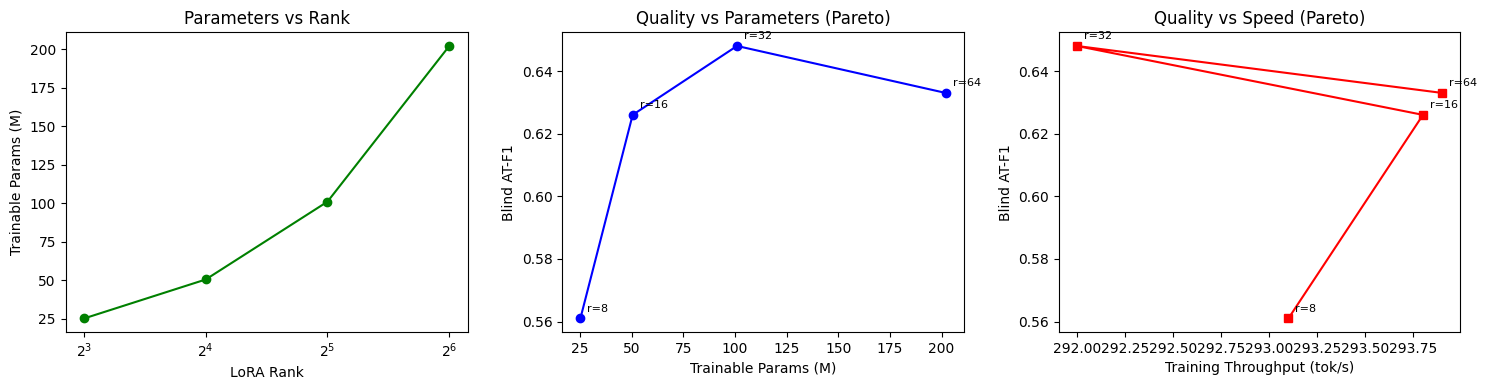

,rank,trainable_params_M,tokens_per_sec,sec_per_step,peak_mem_gb,AT-F1
0,8,25.2,293.1,3.494,43.64,0.561
1,16,50.5,293.8,3.486,43.77,0.626
2,32,101.0,292.0,3.507,44.02,0.648
3,64,202.0,293.9,3.484,44.56,0.633


In [36]:
# ── 7.7 LoRA rank: cost-quality Pareto frontier ──────────────────────────
try:
    start_timer("Profiling: LoRA rank cost curve")

    rank_profile = []
    for r in RANK_SWEEP:
        key = f"r={r}"
        if key not in lora_results:
            continue

        reset_peak_mem()
        pm = setup_lora(prof_model, r=r, alpha=2 * r)
        trainable, total = pm.get_nb_trainable_parameters()

        try:
            result = profile_training_step(pm, prof_tok, prof_data,
                                            n_steps=N_PROFILE_STEPS, batch_size=1,
                                            seq_len=MAX_SEQ_LENGTH, grad_ckpt=True,
                                            label=f"rank_prof_r{r}")
            quality = lora_results[key]["structural"].get("AT-F1", 0)
            rank_profile.append({
                "rank": r,
                "trainable_params_M": round(trainable / 1e6, 1),
                "tokens_per_sec": result["tokens_per_sec"],
                "sec_per_step": result["sec_per_step"],
                "peak_mem_gb": result["peak_mem_gb"],
                "AT-F1": quality,
            })
            print(f"  r={r}: {trainable/1e6:.1f}M params, {result['tokens_per_sec']:.0f} tok/s, "
                  f"peak={result['peak_mem_gb']:.1f} GB, AT-F1={quality:.3f}")
        except RuntimeError:
            print(f"  r={r}: OOM during profiling")
            gc.collect()
            torch.cuda.empty_cache()

        del pm
        gc.collect()
        torch.cuda.empty_cache()

    rank_prof_df = pd.DataFrame(rank_profile)
    stop_timer()

    if len(rank_prof_df) > 1:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].plot(rank_prof_df["rank"], rank_prof_df["trainable_params_M"], "go-")
        axes[0].set_xlabel("LoRA Rank")
        axes[0].set_ylabel("Trainable Params (M)")
        axes[0].set_title("Parameters vs Rank")
        axes[0].set_xscale("log", base=2)

        axes[1].plot(rank_prof_df["trainable_params_M"], rank_prof_df["AT-F1"], "bo-")
        axes[1].set_xlabel("Trainable Params (M)")
        axes[1].set_ylabel("Blind AT-F1")
        axes[1].set_title("Quality vs Parameters (Pareto)")
        for _, row in rank_prof_df.iterrows():
            axes[1].annotate(f"r={int(row['rank'])}", (row["trainable_params_M"], row["AT-F1"]),
                             textcoords="offset points", xytext=(5, 5), fontsize=8)

        axes[2].plot(rank_prof_df["tokens_per_sec"], rank_prof_df["AT-F1"], "rs-")
        axes[2].set_xlabel("Training Throughput (tok/s)")
        axes[2].set_ylabel("Blind AT-F1")
        axes[2].set_title("Quality vs Speed (Pareto)")
        for _, row in rank_prof_df.iterrows():
            axes[2].annotate(f"r={int(row['rank'])}", (row["tokens_per_sec"], row["AT-F1"]),
                             textcoords="offset points", xytext=(5, 5), fontsize=8)

        plt.tight_layout()
        plt.show()
        display(rank_prof_df)
except Exception as e:
    print(f"\n*** PROFILING RANK COST CURVE FAILED: {e} ***\n")
    import traceback; traceback.print_exc()
    rank_prof_df = pd.DataFrame()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [37]:
# ── 7.8 Cost estimation + W&B profiling summary ──────────────────────────
try:
    A100_COST_PER_HOUR = 3.93
    FULL_TRAIN_EXAMPLES = len(clean_tool) + len(clean_plan) + len(clean_exec)
    FULL_EPOCHS = 3

    print("="*70)
    print("TRAINING COST ESTIMATION (A100 80GB)")
    print("="*70)

    cost_rows = []

    if 'batch_df' in dir() and len(batch_df) > 0:
        best_batch_row = batch_df.loc[batch_df["tokens_per_sec"].idxmax()]
        optimal_bs = int(best_batch_row["batch_size"])
        optimal_tps = best_batch_row["tokens_per_sec"]

        avg_tok_per_ex = min(MAX_SEQ_LENGTH, 400)
        total_tokens = FULL_TRAIN_EXAMPLES * FULL_EPOCHS * avg_tok_per_ex

        train_time_s = total_tokens / optimal_tps
        train_time_h = train_time_s / 3600
        train_cost = train_time_h * A100_COST_PER_HOUR

        cost_rows.append({
            "scenario": f"Full training (best config, bs={optimal_bs})",
            "examples": FULL_TRAIN_EXAMPLES,
            "epochs": FULL_EPOCHS,
            "est_tokens": total_tokens,
            "throughput_tok_s": optimal_tps,
            "time_hours": round(train_time_h, 2),
            "cost_usd": round(train_cost, 2),
        })

        plan_tokens = len(clean_plan) * FULL_EPOCHS * avg_tok_per_ex
        cost_rows.append({
            "scenario": "Plan-only (Config A)",
            "examples": len(clean_plan), "epochs": FULL_EPOCHS,
            "est_tokens": plan_tokens,
            "throughput_tok_s": optimal_tps,
            "time_hours": round(plan_tokens / optimal_tps / 3600, 2),
            "cost_usd": round(plan_tokens / optimal_tps / 3600 * A100_COST_PER_HOUR, 2),
        })

        ablation_tokens = 5 * FULL_TRAIN_EXAMPLES * FULL_EPOCHS * avg_tok_per_ex
        cost_rows.append({
            "scenario": "Full 5-config ablation",
            "examples": FULL_TRAIN_EXAMPLES * 5, "epochs": FULL_EPOCHS,
            "est_tokens": ablation_tokens,
            "throughput_tok_s": optimal_tps,
            "time_hours": round(ablation_tokens / optimal_tps / 3600, 2),
            "cost_usd": round(ablation_tokens / optimal_tps / 3600 * A100_COST_PER_HOUR, 2),
        })

        eval_time_h = 30 * 500 / optimal_tps * 12 / 3600
        cost_rows.append({
            "scenario": "All evaluations (12 runs x 30 scenarios)",
            "examples": 30 * 12, "epochs": 1,
            "est_tokens": 30 * 500 * 12,
            "throughput_tok_s": optimal_tps,
            "time_hours": round(eval_time_h, 2),
            "cost_usd": round(eval_time_h * A100_COST_PER_HOUR, 2),
        })
    else:
        print("  (batch_df not available — skipping cost estimation)")

    cost_df = pd.DataFrame(cost_rows)
    display(cost_df)

    if cost_rows:
        total_h = sum(r["time_hours"] for r in cost_rows)
        total_cost = sum(r["cost_usd"] for r in cost_rows)
        print(f"\nTotal estimated A100 time: {total_h:.1f} hours")
        print(f"Total estimated cost: ${total_cost:.2f}")
        print(f"(at ${A100_COST_PER_HOUR}/hr for A100 80GB)")

    # ── Log profiling results to W&B ─────────────────────────────────────────
    wb_run = wb_init("profiling-summary", group="profiling", job_type="analysis",
                     extra_config={"a100_cost_per_hour": A100_COST_PER_HOUR})
    if wb_run:
        if len(cost_df) > 0:
            wb_log_metrics_table("cost_estimation", cost_df)
            wandb.summary["total_est_hours"] = total_h
            wandb.summary["total_est_cost_usd"] = total_cost

        if 'batch_df' in dir() and len(batch_df) > 0:
            wb_log_metrics_table("throughput_vs_batch_size", batch_df)
            wandb.summary["optimal_batch_size"] = optimal_bs
            wandb.summary["optimal_throughput_tok_s"] = optimal_tps

        if 'mem_df' in dir() and len(mem_df) > 0:
            wb_log_metrics_table("memory_by_quantization", mem_df)

        if 'gc_df' in dir() and len(gc_df) > 0:
            wb_log_metrics_table("gradient_checkpointing", gc_df)

        if 'seq_df' in dir() and len(seq_df) > 0:
            wb_log_metrics_table("seq_length_scaling", seq_df)

        wb_finish()

    # Clean up profiling model
    for v in ["prof_model", "prof_tok", "prof_lora"]:
        if v in dir():
            exec(f"del {v}")
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

except Exception as e:
    print(f"\n*** PROFILING COST ESTIMATION FAILED: {e} ***\n")
    import traceback; traceback.print_exc()
    wb_finish()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

TRAINING COST ESTIMATION (A100 80GB)


,scenario,examples,epochs,est_tokens,throughput_tok_s,time_hours,cost_usd
0,"Full training (best config, bs=4)",1912,3,2294400,1414.9,0.45,1.77
1,Plan-only (Config A),1526,3,1831200,1414.9,0.36,1.41
2,Full 5-config ablation,9560,3,11472000,1414.9,2.25,8.85
3,All evaluations (12 runs x 30 scenarios),360,1,180000,1414.9,0.04,0.14



Total estimated A100 time: 3.1 hours
Total estimated cost: $12.17
(at $3.93/hr for A100 80GB)


optimal_batch_size,4
optimal_throughput_tok_s,1414.9
total_est_cost_usd,12.17
total_est_hours,3.1


## 8. Data Ablation (Extended)

Optional: compare all 5 data configurations to confirm that Tool+Plan (Config C) is the best.

| Config | Data | Hypothesis |
|--------|------|-----------|
| **A** | Planning only | Direct question→plan pairs. May memorize without understanding. |
| **B** | Tool-knowledge only | Pure tool awareness. May not learn to compose plans. |
| **C** | Tool-knowledge + Planning | Best of both — know tools, then apply them. (already trained above) |
| **D** | Curriculum: Tool→Plan | Same as C but staged. Tests if order matters. |
| **E** | All data (tool + plan + exec) | Everything available. Do execution traces help? |

In [38]:
# ── Build all data configs and run ablation ───────────────────────────────
try:
    start_timer("Data ablation (3 configs)")

    # Load fresh base model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    base_model, tokenizer = load_base_model(load_in_8bit=True)

    # Config A: Planning only
    config_a_train, config_a_eval = split_train_eval(cap(msgs(clean_plan)))
    # Config B: Tool-knowledge only
    config_b_train, config_b_eval = split_train_eval(cap(msgs(clean_tool)))
    # Config C: already trained as primary — reuse results
    # Config E: All data
    config_e_train, config_e_eval = split_train_eval(cap(msgs(clean_tool) + msgs(clean_plan) + msgs(clean_exec)))

    ablation_configs = {
        "A: Plan-only":  (config_a_train, config_a_eval),
        "B: Tool-only":  (config_b_train, config_b_eval),
        "E: All-data":   (config_e_train, config_e_eval),
    }

    for name, data in ablation_configs.items():
        print(f"{name}: train={len(data[0])}, eval={len(data[1])}")
    print(f"C: Tool+Plan: already trained (AT-F1={all_experiment_results[best_config]['structural'].get('AT-F1', 0):.3f})")

    for config_name, config_data in ablation_configs.items():
        print(f"\n{'='*70}\n TRAINING: {config_name}\n{'='*70}")

        try:
            train_data, eval_data = config_data
            peft_model = setup_lora(base_model)
            _, hist = train_model(peft_model, tokenizer, train_data, eval_data,
                                      str(OUTPUT_DIR / f"data_{config_name}"),
                                      run_name=config_name,
                                      wb_group="data-ablation",
                                      wb_extra_config={"data_config": config_name})

            abl_blind = run_eval(peft_model, tokenizer, test_scenarios, BLIND_PROMPT, f"{config_name} Blind")
            abl_summary = summarize_metrics(abl_blind)
            abl_judge = run_judge_eval(abl_blind, test_scenarios)
            abl_judge_summary = summarize_judge(abl_judge)

            if wandb.run is not None:
                wandb.summary.update({
                    "eval/AT-F1": abl_summary.get("AT-F1", 0),
                    "eval/ArgKey-F1": abl_summary.get("ArgKey-F1", 0),
                })
                for k, v in abl_judge_summary.items():
                    if k != "n":
                        wandb.summary[f"eval/judge_{k}"] = v
                wb_log_eval_table(abl_blind, abl_judge, f"predictions_{config_name}")
            wb_finish()

            all_experiment_results[config_name] = {
                "structural": abl_summary, "judge": abl_judge_summary,
                "raw_results": abl_blind, "raw_judge": abl_judge,
            }
            print(f"{config_name} blind AT-F1: {abl_summary.get('AT-F1', 0):.3f}")

            del peft_model
        except Exception as inner_e:
            print(f"  *** {config_name} FAILED: {inner_e} ***")
            import traceback; traceback.print_exc()
            wb_finish()
            if "peft_model" in dir():
                del peft_model

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    stop_timer()

    # Clean up
    del base_model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

except Exception as e:
    print(f"\n*** DATA ABLATION FAILED: {e} ***\n")
    import traceback; traceback.print_exc()
    wb_finish()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


>>> Starting: Data ablation (3 configs)
Loading google/gemma-4-E4B-it [8-bit]...


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

A: Plan-only: train=1449, eval=77
B: Tool-only: train=291, eval=16
E: All-data: train=1816, eval=96
C: Tool+Plan: already trained (AT-F1=0.635)

 TRAINING: A: Plan-only
LoRA r=16, alpha=32 -> trainable: 50,499,584 / 7,991,600,416 (0.63%)


Tokenizing train dataset:   0%|          | 0/1449 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/77 [00:00<?, ? examples/s]

...

E: All-data Blind:   0%|          | 0/30 [00:00<?, ?it/s]

Gemini judge:   0%|          | 0/30 [00:00<?, ?it/s]

  Judged 30/30 scenarios


eval/AT-F1,▁
eval/ArgKey-F1,▁
eval/agent_%,▁
eval/entropy,█▆▄▃▂▁▁▁▁
eval/format_%,▁
eval/loss,█▅▃▂▂▁▁▁▁
eval/mean_token_accuracy,▁▄▅▆▇████
eval/n,▁
eval/num_tokens,▁▂▃▄▅▆▇██
eval/runtime,▇▇▄▅▁▄▄█▆
+11,...


E: All-data blind AT-F1: 0.575
<<< Data ablation (3 configs): 341m 20s



=== DATA ABLATION: ALL CONFIGS (Blind Mode) ===


,config,n,format_%,AT-F1,ArgKey-F1,agent_%,tool_%,judge_n,judge_correctness,judge_agent_routing,judge_tool_selection,judge_argument_quality,judge_efficiency,judge_dependency_correctness,judge_overall
0,C: Tool+Plan,30,100.000,0.635,0.630,0.975,0.949,30,2.828,4.310,3.966,3.448,3.241,4.552,3.600
1,A: Plan-only,30,100.000,0.636,0.633,0.988,0.929,30,3.300,3.967,3.833,3.867,3.767,4.667,3.900
2,B: Tool-only,30,93.333,0.211,0.296,0.985,0.433,30,1.633,3.133,1.800,2.267,2.867,3.867,2.594
3,E: All-data,30,100.000,0.575,0.631,1.000,0.971,30,2.867,4.400,3.833,3.733,3.300,4.600,3.789



Best data config: A: Plan-only (AT-F1=0.636)


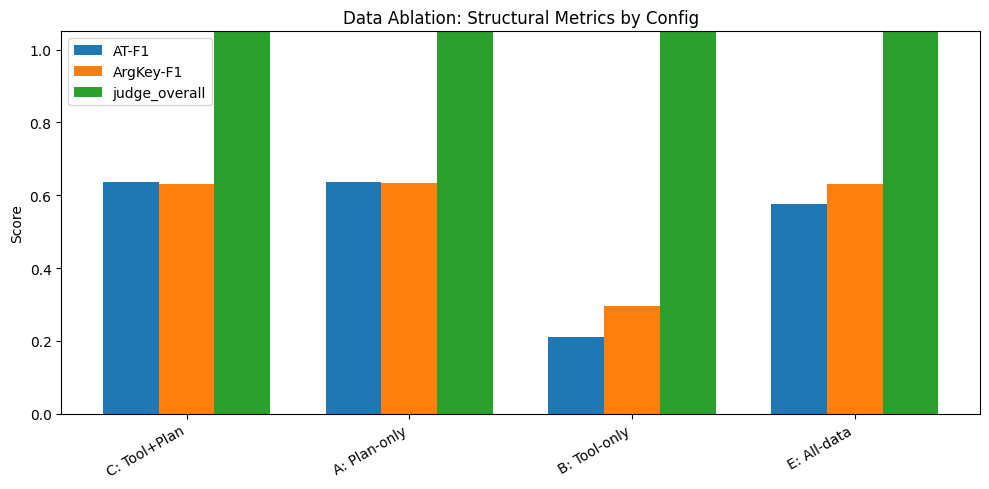

best_data_config,A: Plan-only


In [39]:
# ── Data ablation comparison table + W&B ──────────────────────────────────
try:
    ablation_rows = []
    for name, res in all_experiment_results.items():
        if "Baseline" in name:
            continue
        row = {"config": name}
        row.update(res.get("structural", {}))
        for k, v in res.get("judge", {}).items():
            row[f"judge_{k}"] = v
        ablation_rows.append(row)

    data_ablation_df = pd.DataFrame(ablation_rows)
    print("\n=== DATA ABLATION: ALL CONFIGS (Blind Mode) ===")
    display(data_ablation_df.round(3))

    # Confirm best
    ablation_best = max(ablation_rows, key=lambda r: r.get("AT-F1", 0))
    print(f"\nBest data config: {ablation_best['config']} (AT-F1={ablation_best.get('AT-F1', 0):.3f})")

    # Log to W&B
    wb_run = wb_init("data-ablation-summary", group="data-ablation", job_type="analysis")
    if wb_run:
        wb_log_metrics_table("data_ablation_comparison", data_ablation_df)
        wandb.summary["best_data_config"] = ablation_best["config"]

        # Grouped bar chart
        fig, ax = plt.subplots(figsize=(10, 5))
        x = np.arange(len(data_ablation_df))
        w = 0.25
        for j, metric in enumerate(["AT-F1", "ArgKey-F1", "judge_overall"]):
            if metric in data_ablation_df.columns:
                ax.bar(x + j * w, data_ablation_df[metric].fillna(0), w, label=metric)
        ax.set_xticks(x + w)
        ax.set_xticklabels(data_ablation_df["config"], rotation=30, ha="right")
        ax.set_ylabel("Score")
        ax.set_title("Data Ablation: Structural Metrics by Config")
        ax.legend()
        ax.set_ylim(0, 1.05)
        plt.tight_layout()
        wb_log_figure("data_ablation_chart")
        plt.show()

        wb_finish()
except Exception as e:
    print(f"\n*** DATA ABLATION SUMMARY FAILED: {e} ***\n")
    import traceback; traceback.print_exc()
    wb_finish()

## Summary

This notebook tested whether Gemma 4 E4B can internalize MCP tool descriptions through QLoRA fine-tuning.

**Key findings** (populate after running):
- **Best data config**: Tool-knowledge + Planning (Config C or D) expected to outperform planning-only
- **Best LoRA rank**: Higher rank may improve AT-F1 but watch for overfitting
- **Forgetting**: LoRA fine-tuning typically retains >95% of general capabilities
- **Token savings**: Blind mode saves ~400+ tokens per query vs informed mode

**Profiling insights** (populate after running):
- **Optimal batch size**: Largest that fits in 80GB without OOM
- **Gradient checkpointing**: Memory saved vs speed cost tradeoff
- **LoRA rank Pareto**: Quality vs compute cost frontier
- **Inference bottleneck**: Which CUDA operations dominate generation time
- **Estimated full-run cost**: Total A100 hours and $ for the complete experiment

**Next step**: Use the best configuration to train the planner model, then build the executor model (Step 2).